# RETO 3: Viviendas de Uso Turístico (VUT) en Torrevieja 

Las Viviendas de Uso Turístico (VUT) constituyen una parte central del sistema de alojamiento de Torrevieja. El objetivo de este reto es analizar su dimensión, evolución y distribución territorial, así como discutir su papel dentro del modelo turístico residencial.

## 1. INTRODUCCIÓN

#### A. Contexto y relevancia del análisis

Torrevieja es un municipio con un modelo turístico muy residencial, es decir, la mayor parte de los turistas no se aloja en hoteles sino en viviendas, ya sean propias o alquiladas. Muchas de estas viviendas se comercializan a través de plataformas digitales como Airbnb o Booking. Por lo tanto, las VUT son un indicador clave para calcular la presión turística sobre la ciudad y la evolución del mercado de las viviendas locales.

Una VUT es difícil de regular y cuantificar con certeza, ya que están distribuidas por toda la ciudad, no siempre están activas y muchas viviendas no se registran. Por eso, es importante trabajar con datos de múltiples fuentes.

#### B. Definición de VUT

Una Vivienda de Uso Turístico es un inmueble (piso, apartamento o casa) amueblado y equipado que se cede al completo a terceros por un precio, con fines turísticos o vacacionales, durante estancias cortas (generalmente menos de 31 días). Se alquilan principalmente a través de plataformas online y, para operar legalmente en la Comunitat Valenciana, deben estar inscritas en el *Registro de Turisme de la Comunitat Valenciana*, con el identificador `CV-VUT-XXXXXX-A`.

Para este trabajo es importante distinguir entre:
- **VUT registradas**: las que figuran en el registro oficial, que son las únicas legalmente operativas.
- **Oferta real en plataformas (Airbnb, Booking...)**: puede incluir viviendas no registradas o con datos distintos a los oficiales. Estas viviendas no son accesibles con los datos disponibles, por lo que, seguramente, subestimemos la oferta real.

#### C. Fuentes de datos utilizadas

| Dataset | Fuente | Periodo |
|---|---|---|
| `obtenerDocumentoSForms.csv` | Registro de Turisme de la CV | 1996-2025 |
| `lista-de-viviendas-turisticas.csv` | GVA Open Data | 1993-2025 |
| `viviendas_turisticas_plazas_y_plazas_por_vivienda_turistica.csv` | INE (EHAT) | 2020-2025 (semestral) |
| `porcentaje_viviendas_turisticas_sobre_el_total_de_viviendas_censadas.csv` | INE (EHAT) | 2020-2025 (semestral) |
| `evolucion_viviendas_2001_2021.csv` | INE (Censos de Población y Viviendas) | 2001, 2011, 2021 |
| `precios_vivienda.csv` | Fuente secundaria | 2006-2026 |
| `precio_alquileres.csv` | Fuente secundaria | 2008-2026 |

Combinando estas fuentes podemos contrastar la información: el registro oficial nos da detalles a nivel de vivienda individual, el INE nos da estadísticas oficiales y con las series de precios podemos ver el impacto sobre el mercado inmobiliario.

#### D. Supuestos y advertencias metodológicas

Antes de entrar en el análisis, conviene ser transparentes sobre las hipótesis que asumimos y sus implicaciones:

- **Bajas no registradas**: `obtenerDocumentoSForms.csv` solo contiene las VUT actualmente dadas de alta, sin información sobre bajas. La evolución por `fecha_alta` sobreestima ligeramente el stock en cada año, ya que no descuenta las viviendas que han dejado de operar.
- **Estacionalidad del INE**: La *Encuesta de Ocupación en Apartamentos Turísticos (EHAT)* se publica en febrero y agosto, representando respectivamente la temporada baja y alta. Esto significa que las cifras del INE oscilan sistemáticamente según el momento de medición, y hay que interpretarlas teniendo en cuenta la estación.
- **Código postal como proxy geográfico**: Usamos el CP como única variable de localización interna, lo que implica una granularidad limitada. Dentro de un mismo CP puede haber zonas con realidades muy distintas.
- **Correlación vs. causalidad**: Cuando analicemos la relación entre VUT y precios, veremos correlaciones altas, pero no podemos concluir causalidad directa. Ambas variables tienen tendencia creciente en el tiempo y eso, por sí solo, genera correlación aunque no haya relación directa.


## 2. INFORMACIÓN ENCONTRADA Y PREPARACIÓN DE LOS DATOS

Los datos provienen de tres administraciones distintas (Generalitat Valenciana, INE y fuentes secundarias locales), con formatos, separadores y codificaciones diferentes. Antes de poder analizarlos, toca hacer el trabajo menos vistoso pero más crítico: entender qué hay en cada archivo, detectar errores y dejarlos en un formato limpio y consistente.

Organizamos la preparación en cuatro bloques según la fuente:
- **A**: Registro oficial de VUT (análisis individual + temporal + territorial)
- **B**: Encuesta INE de plazas y porcentaje sobre el total censal
- **C**: Parque total de viviendas (Censos 2001, 2011, 2021)
- **D**: Series de precios de compraventa y alquiler


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.cm as cm
from matplotlib.patches import Patch
import warnings
from IPython.display import display
warnings.filterwarnings('ignore')
import os

### A. REGISTRO OFICIAL DE VUT (`obtenerDocumentoSForms.csv`)

#### 1. Identificación y origen
Este archivo lo obtenemos del *Registro de Turisme de la Comunitat Valenciana*. Contiene una fila por cada VUT dada de alta en Torrevieja, con información sobre su localización (código postal, dirección), características físicas (superficie, plazas, dormitorios) y fecha de inscripción. Es la fuente más rica para el análisis temporal y territorial, aunque tiene la limitación importante de no incluir bajas.

#### 2. EDA y evaluación de calidad
Antes de limpiar nada, miramos qué tenemos: dimensiones, tipos de columnas, nulos, y la distribución por código postal.


In [2]:
# cargamos el registro oficial de VUT
ruta_vut = r'C:\Users\itsas\OneDrive - UNIVERSIDAD ALICANTE\Escritorio\MASTER\ASIGNATURAS\2CUATRI\MINERÍA DE DATOS\Grupal\Practica3\3RETO\datasets\obtenerDocumentoSForms.csv'
df_vut = pd.read_csv(ruta_vut, sep=';', encoding='utf-8', on_bad_lines='skip')

# miramos qué tiene el dataset
print("EDA - REGISTRO VUT (obtenerDocumentoSForms.csv)")
print(f"\n1. Dimensiones: {df_vut.shape[0]:,} filas x {df_vut.shape[1]} columnas")

print("\n2. Columnas y tipos de datos:")
df_vut.info()

print("\n3. Primeras filas:")
display(df_vut.head())

print("\n4. Nulos (solo columnas con alguno):")
nulos = df_vut.isnull().sum()
nulos = nulos[nulos > 0]
tabla = nulos.to_frame(name='Nulos')
tabla['Porcentaje'] = (tabla['Nulos'] / len(df_vut)) * 100
display(tabla)

print("\n5. Registros con 'Plazas totales' == 0 (formularios incompletos):")
plazas_totales = (df_vut['Plazas totales'] == 0).sum()
print(f"  {plazas_totales} registros con 0 plazas --> se eliminarán")

print("\n6. Distribución por código postal:")  # solo hay 8 CPs en Torrevieja
cp = df_vut['CP'].value_counts().head(8).to_frame(name='Nº VUT')
display(cp)


EDA - REGISTRO VUT (obtenerDocumentoSForms.csv)

1. Dimensiones: 9,922 filas x 19 columnas

2. Columnas y tipos de datos:
<class 'pandas.DataFrame'>
RangeIndex: 9922 entries, 0 to 9921
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   N de inscripcion           9922 non-null   str    
 1   Nombre                     8157 non-null   str    
 2   Provincia                  9922 non-null   str    
 3   Municipio                  9922 non-null   str    
 4   CP                         9922 non-null   int64  
 5   Dirección                  9922 non-null   str    
 6   Sitio web                  61 non-null     str    
 7   Fecha alta                 9922 non-null   str    
 8   Referencia catastral       9919 non-null   str    
 9   Código registral único     94 non-null     str    
 10  Rural                      9922 non-null   str    
 11  Superficie                 9838 non-null   str   

,N de inscripcion,Nombre,Provincia,Municipio,CP,Dirección,Sitio web,Fecha alta,Referencia catastral,Código registral único,Rural,Superficie,Plazas totales,Estudio,Habitaciones dobles,Plazas dobles,Habitaciones individuales,Plazas individuales,Total dormitorios
0,CV-VUT0517287-A,PAWEL STANISLAW POKRYWA,ALICANTE/ALACANT,TORREVIEJA,3180,"CL MAESTRO FRANCISCO CASANOV, 51, Es:5 Pl:02 P...",NaN,19/06/2025,4467201YH0046N0263AJ,NaN,N,62,4,N,2.0,4,0.0,0,2.0
1,CV-VUT0517499-A,NaN,ALICANTE/ALACANT,TORREVIEJA,3188,"CL MAYOR-MATA, 75, Es:1 Pl:02 Pt:J",NaN,02/07/2025,5917601YH0151N0049KL,NaN,N,76,6,N,3.0,6,0.0,0,3.0
2,CV-VUT0517500-A,NaN,ALICANTE/ALACANT,TORREVIEJA,3182,"CL VIRGEN DE LA PALOMA, 41, Es:1 Pl:01 Pt:0F",NaN,02/07/2025,4664107YH0046S0008PT,NaN,N,87,6,N,2.0,4,2.0,2,4.0
3,CV-VUT0517950-A,NaN,ALICANTE/ALACANT,TORREVIEJA,3181,"CL SAN PASCUAL, 71, Es:1 Pl:03 Pt:G",NaN,29/07/2025,3262318YH0036S0046PR,NaN,N,33,2,N,1.0,2,0.0,0,1.0
4,CV-VUT0518418-A,apestrella,ALICANTE/ALACANT,TORREVIEJA,3180,"CL BAZAN, 90, Es:D Pl:01 Pt:05",NaN,11/09/2025,3667401YH0036N0418SS,NaN,N,81,4,N,2.0,4,0.0,0,2.0



4. Nulos (solo columnas con alguno):


,Nulos,Porcentaje
Nombre,1765,17.788752
Sitio web,9861,99.385205
Referencia catastral,3,0.030236
Código registral único,9828,99.052610
Superficie,84,0.846604
Habitaciones dobles,29,0.292280
Habitaciones individuales,41,0.413223
Total dormitorios,5,0.050393



5. Registros con 'Plazas totales' == 0 (formularios incompletos):
  29 registros con 0 plazas --> se eliminarán

6. Distribución por código postal:


,Nº VUT
CP,
3180,5866
3185,964
3183,949
3182,825
3188,552
3181,322
3184,304
3186,140


Del EDA inicial extraemos lo más relevante:

- El dataset tiene **9.922 registros** y **19 columnas**, todos de Torrevieja. No hay contaminación con otros municipios.
- La columna `Nombre` tiene nulos en aproximadamente el 30% de las filas. Es normal: muchos propietarios no asignan nombre comercial a su VUT. No nos afecta porque no usamos esa variable.
- `Código registral único` también tiene bastantes nulos (~50%), pero podemos trabajar con el resto de identificadores.
- **El problema clave está en `Plazas totales`**: hay registros con valor `0`, que corresponden a formularios enviados sin rellenar ese campo. Estos registros hay que eliminarlos porque sin plazas no tiene sentido incluirlos en el análisis.
- La columna `Fecha alta` viene en formato `dd/mm/yyyy`, así que habrá que convertirla a datetime.
- Casi todas las VUT se concentran en el CP `03180` (Centro), como se puede ver en la distribución.

#### 3. Limpieza y transformación


In [3]:
# trabajamos sobre una copia para no tocar el original
df_vut_limpio = df_vut.copy()

# pasamos la fecha a datetime (si algo falla, se queda como NaT)
df_vut_limpio['Fecha alta'] = pd.to_datetime(df_vut_limpio['Fecha alta'], format='%d/%m/%Y', errors='coerce')
# sacamos año y mes por separado, que los usaremos mucho después
df_vut_limpio['Año_alta'] = df_vut_limpio['Fecha alta'].dt.year
df_vut_limpio['Mes_alta'] = df_vut_limpio['Fecha alta'].dt.month

# convertimos las columnas numéricas (a veces vienen como string)
df_vut_limpio['Plazas totales']    = pd.to_numeric(df_vut_limpio['Plazas totales'], errors='coerce')
df_vut_limpio['Total dormitorios'] = pd.to_numeric(df_vut_limpio['Total dormitorios'], errors='coerce')
df_vut_limpio['Superficie']        = pd.to_numeric(df_vut_limpio['Superficie'], errors='coerce')

# eliminamos los registros con plazas == 0 (formularios incompletos, no tienen utilidad)
n_antes = len(df_vut_limpio)
df_vut_limpio = df_vut_limpio[df_vut_limpio['Plazas totales'] > 0].copy()
n_despues = len(df_vut_limpio)
print(f"Registros eliminados por Plazas == 0: {n_antes - n_despues} ({(n_antes - n_despues)/n_antes*100:.1f}%)")

# estandarizamos el CP a string de 5 dígitos (ponemos el 0 delante si falta)
df_vut_limpio['CP'] = df_vut_limpio['CP'].astype(int).astype(str).str.zfill(5)

# quitamos el año 2026 porque está incompleto y distorsionaría las tendencias
df_vut_limpio = df_vut_limpio[df_vut_limpio['Año_alta'] != 2026]

print("\nDataset limpio:")
print(f"  - Registros válidos: {len(df_vut_limpio):,}")
print(f"  - Plazas totales: {df_vut_limpio['Plazas totales'].sum():,.0f}")
print(f"  - Media de plazas por VUT: {df_vut_limpio['Plazas totales'].mean():.2f}")
print(f"  - Periodo: {df_vut_limpio['Año_alta'].min()} – {df_vut_limpio['Año_alta'].max()}")

print("\nEstadísticas de las variables numéricas:")
display(df_vut_limpio[['Plazas totales', 'Total dormitorios', 'Superficie']].describe().round(2))


Registros eliminados por Plazas == 0: 29 (0.3%)

Dataset limpio:
  - Registros válidos: 9,694
  - Plazas totales: 38,362
  - Media de plazas por VUT: 3.96
  - Periodo: 1996 – 2025

Estadísticas de las variables numéricas:


,Plazas totales,Total dormitorios,Superficie
count,9694.00,9691.00,9607.00
mean,3.96,2.03,73.79
std,1.46,0.77,37.91
min,1.00,0.00,0.00
25%,3.00,2.00,54.00
50%,4.00,2.00,66.00
75%,4.00,2.00,84.00
max,16.00,8.00,870.00


In [4]:
# guardamos el CSV limpio
ruta_limpio = r'C:\Users\itsas\OneDrive - UNIVERSIDAD ALICANTE\Escritorio\MASTER\ASIGNATURAS\2CUATRI\MINERÍA DE DATOS\Grupal\Practica3\3RETO\datasets limpios'
os.makedirs(ruta_limpio, exist_ok=True)

df_vut_limpio.to_csv(os.path.join(ruta_limpio, 'vut_limpio.csv'),
                     index=False, sep=';', encoding='utf-8-sig')
print("Archivo guardado: vut_limpio.csv")


Archivo guardado: vut_limpio.csv


Tras la limpieza nos quedamos con algo más de **9.700 VUT válidas**. Para tener una primera intuición de cómo se distribuyen, representamos la evolución anual del número de altas y de las plazas generadas. Esperamos ver un crecimiento sostenido con alguna interrupción alrededor del COVID (2020-2021).


,Plazas totales,Nº VUT
Año_alta,,
1996,4,1
1998,18,5
2000,60,15
2005,30,8
2008,6,1
2009,20,5
2013,100,25
2014,51,11
2015,181,46


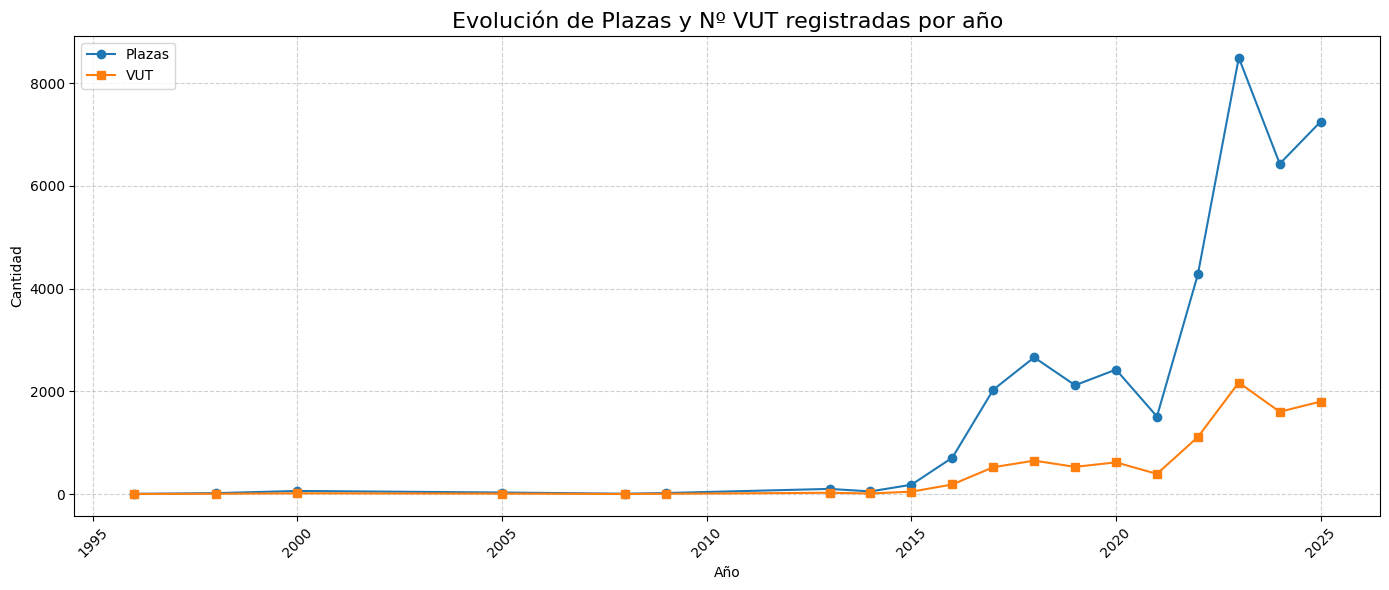

In [5]:
# agrupamos por año para ver cuántas VUT y plazas se dieron de alta cada año
datos = df_vut_limpio.groupby('Año_alta').agg({
    'Plazas totales': 'sum',
    'Año_alta': 'count'
}).rename(columns={'Año_alta': 'Nº VUT'})

display(datos)

plt.figure(figsize=(14, 6))

plt.plot(datos.index, datos['Plazas totales'], marker='o', linestyle='-', label='Plazas')
plt.plot(datos.index, datos['Nº VUT'],          marker='s', linestyle='-', label='VUT')

plt.title('Evolución de Plazas y Nº VUT registradas por año', fontsize=16)
plt.xlabel('Año')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


La gráfica confirma el patrón que esperábamos, pero con una magnitud llamativa: el crecimiento no es lineal, sino que se acelera claramente a partir de 2017-2018. La caída de 2020-2021 por el COVID es visible, pero la recuperación posterior es casi inmediata y alcanza valores récord en 2022-2023. Este perfil en "curva de aceleración" es una primera señal de que el sector VUT en Torrevieja no se ha estabilizado, sino que sigue en expansión activa.

La diferencia entre la curva de VUT y la de plazas se mantiene bastante constante, lo que sugiere que el tamaño medio de las viviendas nuevas no ha variado mucho a lo largo del tiempo (aproximadamente 4 plazas por VUT de media).


### B. DATOS INE: VIVIENDAS, PLAZAS Y PORCENTAJE SOBRE EL TOTAL CENSAL

#### 1. Identificación y origen
El INE publica semestralmente datos sobre VUT en municipios turísticos a través de la *Encuesta de Ocupación en Apartamentos Turísticos (EHAT)*. Para Torrevieja disponemos de dos archivos complementarios:
- `viviendas_turisticas_plazas_y_plazas_por_vivienda_turistica.csv`: número de VUT, plazas y ratio plazas/VUT.
- `porcentaje_viviendas_turisticas_sobre_el_total_de_viviendas_censadas.csv`: qué porcentaje del parque total representan las VUT.

Los dos archivos tienen cortes en **febrero** (temporada baja) y **agosto** (temporada alta), desde 2020 hasta 2025. Esto nos permite comparar no solo la tendencia, sino también la oscilación estacional dentro de cada año.

#### 2. Estado inicial y EDA
Los números vienen en formato europeo (punto como separador de miles, coma como decimal) y el campo `Periodo` usa el formato `AAAAMmm` (ej. `2024M08`), así que hay que parsearlos antes de operar con ellos.

#### 3. Limpieza y transformación


In [6]:
# cargamos los dos archivos del INE
ruta_plazas = r'C:\Users\itsas\OneDrive - UNIVERSIDAD ALICANTE\Escritorio\MASTER\ASIGNATURAS\2CUATRI\MINERÍA DE DATOS\Grupal\Practica3\3RETO\datasets\viviendas_turisticas_plazas_y_plazas_por_vivienda_turistica.csv'
ruta_pct    = r'C:\Users\itsas\OneDrive - UNIVERSIDAD ALICANTE\Escritorio\MASTER\ASIGNATURAS\2CUATRI\MINERÍA DE DATOS\Grupal\Practica3\3RETO\datasets\porcentaje_viviendas_turisticas_sobre_el_total_de_viviendas_censadas.csv'

df_plazas = pd.read_csv(ruta_plazas, sep=';', encoding='latin-1')
df_pct    = pd.read_csv(ruta_pct, sep=';', encoding='latin-1')

print("EDA - plazas viviendas turísticas (INE)")
display(df_plazas.head())
print(f"Dimensiones: {df_plazas.shape}")
print(f"Tipos en 'Viviendas y plazas': {df_plazas['Viviendas y plazas'].unique()}")

print("\nEDA - porcentaje VUT sobre parque censado (INE)")
display(df_pct.head())
print(f"Dimensiones: {df_pct.shape}")

# función para limpiar números en formato europeo (. como miles, , como decimal)
def limpiar_numero(n):
    return pd.to_numeric(
        n.astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False),
        errors='coerce'
    )

# función para parsear el formato de periodo 'AAAAMmm' a datetime
def parsear_periodo(n):
    return pd.to_datetime(n, format='%YM%m', errors='coerce')

# limpiamos el dataframe de plazas
df_plazas_limpio = df_plazas.copy()
df_plazas_limpio['Total']  = limpiar_numero(df_plazas_limpio['Total'])
df_plazas_limpio['Fecha']  = parsear_periodo(df_plazas_limpio['Periodo'])
df_plazas_limpio['Año']    = df_plazas_limpio['Fecha'].dt.year
df_plazas_limpio['Mes']    = df_plazas_limpio['Fecha'].dt.month
df_plazas_limpio['Temporada'] = df_plazas_limpio['Mes'].map({2: 'Invierno', 8: 'Verano'})

# pivotamos para tener una columna por tipo de métrica (VUT, Plazas, Ratio)
df_plazas_pivot = df_plazas_limpio.pivot_table(
    index=['Fecha', 'Año', 'Mes', 'Temporada'],
    columns='Viviendas y plazas',
    values='Total'
).reset_index()
df_plazas_pivot.columns.name = None

print("\nDataset plazas pivotado:")
display(df_plazas_pivot.sort_values('Fecha'))

# limpiamos el dataframe de porcentajes
df_pct_limpio = df_pct.copy()
df_pct_limpio['Total']     = limpiar_numero(df_pct_limpio['Total'])
df_pct_limpio['Fecha']     = parsear_periodo(df_pct_limpio['Periodo'])
df_pct_limpio['Año']       = df_pct_limpio['Fecha'].dt.year
df_pct_limpio['Mes']       = df_pct_limpio['Fecha'].dt.month
df_pct_limpio['Temporada'] = df_pct_limpio['Mes'].map({2: 'Invierno', 8: 'Verano', 5: 'Primavera', 11: 'Otoño'})

print("\nDataset porcentaje limpio:")
display(df_pct_limpio[['Fecha', 'Temporada', 'Total']].sort_values('Fecha'))


EDA - plazas viviendas turísticas (INE)


,Total Nacional,Comunidades y Ciudades Autónomas,Provincias,Municipios,Viviendas y plazas,Periodo,Total
0,Total Nacional,10 Comunitat Valenciana,03 Alicante/Alacant,03133 Torrevieja,Viviendas turísticas,2025M11,3.647
1,Total Nacional,10 Comunitat Valenciana,03 Alicante/Alacant,03133 Torrevieja,Viviendas turísticas,2025M05,4.927
2,Total Nacional,10 Comunitat Valenciana,03 Alicante/Alacant,03133 Torrevieja,Viviendas turísticas,2024M11,5.140
3,Total Nacional,10 Comunitat Valenciana,03 Alicante/Alacant,03133 Torrevieja,Viviendas turísticas,2024M08,5.411
4,Total Nacional,10 Comunitat Valenciana,03 Alicante/Alacant,03133 Torrevieja,Viviendas turísticas,2024M02,4.454


Dimensiones: (36, 7)
Tipos en 'Viviendas y plazas': <StringArray>
['Viviendas turísticas', 'Plazas', 'Plazas por vivienda turística']
Length: 3, dtype: str

EDA - porcentaje VUT sobre parque censado (INE)


,Total Nacional,Comunidades y Ciudades Autónomas,Provincias,Municipios,Periodo,Total
0,Total Nacional,10 Comunitat Valenciana,03 Alicante/Alacant,03133 Torrevieja,2025M11,"2,97"
1,Total Nacional,10 Comunitat Valenciana,03 Alicante/Alacant,03133 Torrevieja,2025M05,"4,01"
2,Total Nacional,10 Comunitat Valenciana,03 Alicante/Alacant,03133 Torrevieja,2024M11,"4,19"
3,Total Nacional,10 Comunitat Valenciana,03 Alicante/Alacant,03133 Torrevieja,2024M08,"4,41"
4,Total Nacional,10 Comunitat Valenciana,03 Alicante/Alacant,03133 Torrevieja,2024M02,"3,63"


Dimensiones: (12, 6)

Dataset plazas pivotado:


,Fecha,Año,Mes,Temporada,Plazas,Plazas por vivienda turística,Viviendas turísticas
0,2020-08-01,2020,8,Verano,18279.0,4.76,3839.0
1,2021-02-01,2021,2,Invierno,16917.0,4.74,3571.0
2,2021-08-01,2021,8,Verano,16527.0,4.75,3476.0
3,2022-02-01,2022,2,Invierno,16100.0,4.74,3397.0
4,2022-08-01,2022,8,Verano,17349.0,4.72,3679.0
5,2023-02-01,2023,2,Invierno,17679.0,4.73,3740.0
6,2023-08-01,2023,8,Verano,21594.0,4.71,4580.0
7,2024-02-01,2024,2,Invierno,21022.0,4.72,4454.0
8,2024-08-01,2024,8,Verano,25488.0,4.71,5411.0



Dataset porcentaje limpio:


,Fecha,Temporada,Total
11,2020-08-01,Verano,3.14
10,2021-02-01,Invierno,2.92
9,2021-08-01,Verano,2.84
8,2022-02-01,Invierno,2.78
7,2022-08-01,Verano,3.01
6,2023-02-01,Invierno,3.06
5,2023-08-01,Verano,3.73
4,2024-02-01,Invierno,3.63
3,2024-08-01,Verano,4.41
2,2024-11-01,Otoño,4.19


Los datos del INE son más escasos en cuanto a rango temporal (2020-2025) pero muy valiosos porque son independientes del registro oficial y permiten ver la oscilación estacional. Un aspecto importante a retener: las cifras de **verano siempre son superiores** a las de invierno, lo que refleja que hay VUT que solo se activan en temporada alta. Esto es coherente con el modelo turístico de la ciudad y explica parte de la diferencia que luego veremos entre el porcentaje de febrero y el de agosto.


In [7]:
# guardamos los dos CSVs limpios
df_plazas_pivot.to_csv(os.path.join(ruta_limpio, 'plazas_limpio.csv'),
                       index=False, sep=';', encoding='utf-8-sig')
df_pct_limpio.to_csv(os.path.join(ruta_limpio, 'porcentaje_limpio.csv'),
                     index=False, sep=';', encoding='utf-8-sig')
print("Archivos guardados: plazas_limpio.csv y porcentaje_limpio.csv")


Archivos guardados: plazas_limpio.csv y porcentaje_limpio.csv


### C. EVOLUCIÓN DEL PARQUE DE VIVIENDAS (Censo INE 2001, 2011, 2021)

#### 1. Identificación y origen
El INE publica el *Censo de Población y Viviendas* cada 10 años. El archivo `evolucion_viviendas_2001_2021.csv` recoge los tres últimos cortes (2001, 2011, 2021) con la distribución entre viviendas principales, secundarias y vacías.

Esta fuente es imprescindible para contextualizar el peso del sector VUT: necesitamos saber sobre qué base de viviendas totales operan, y en particular cuántas viviendas no principales hay disponibles para convertirse en VUT.

#### 2. Observaciones del EDA
- Solo hay 3 filas (una por censo), lo que limita el análisis a comparaciones puntuales entre décadas.
- Los datos de 2021 tienen `NaN` en `Viviendas_Secundarias` y `Viviendas_Vacias` porque el Censo de 2021 usó una metodología distinta que todavía no desagrega completamente esas categorías. Esto nos impide hacer comparaciones directas con los años anteriores en esas variables, y no tiene sentido imputar valores sin datos oficiales.

#### 3. Transformación


In [8]:
# cargamos los datos censales del parque de viviendas
ruta_censo = r'C:\Users\itsas\OneDrive - UNIVERSIDAD ALICANTE\Escritorio\MASTER\ASIGNATURAS\2CUATRI\MINERÍA DE DATOS\Grupal\Practica3\3RETO\datasets\evolucion_viviendas_2001_2021.csv'
df_censo = pd.read_csv(ruta_censo, sep=';')

print("EDA – evolucion_viviendas_2001_2021.csv")
print(f"Dimensiones: {df_censo.shape}")
display(df_censo)
print("\nNulos por columna:")
print(df_censo.isnull().sum())

# calculamos qué % del parque son viviendas no principales (en los años con datos)
# esto es útil para entender la "bolsa" potencial de viviendas que podrían ser VUT
df_censo['Pct_No_Principales'] = (df_censo['Viviendas_No_Principales'] / df_censo['Total_Viviendas'] * 100).round(1)
df_censo['Pct_Secundarias']    = (df_censo['Viviendas_Secundarias'] / df_censo['Total_Viviendas'] * 100).round(1)

print("\nDataset censal con porcentajes:")
display(df_censo)


EDA – evolucion_viviendas_2001_2021.csv
Dimensiones: (3, 6)


,Año,Total_Viviendas,Viviendas_Principales,Viviendas_No_Principales,Viviendas_Secundarias,Viviendas_Vacias
0,2001,102363,21565,80643,61745.0,18898.0
1,2011,122327,39855,82472,62585.0,19887.0
2,2021,122736,36829,85907,NaN,NaN



Nulos por columna:
Año                         0
Total_Viviendas             0
Viviendas_Principales       0
Viviendas_No_Principales    0
Viviendas_Secundarias       1
Viviendas_Vacias            1
dtype: int64

Dataset censal con porcentajes:


,Año,Total_Viviendas,Viviendas_Principales,Viviendas_No_Principales,Viviendas_Secundarias,Viviendas_Vacias,Pct_No_Principales,Pct_Secundarias
0,2001,102363,21565,80643,61745.0,18898.0,78.8,60.3
1,2011,122327,39855,82472,62585.0,19887.0,67.4,51.2
2,2021,122736,36829,85907,NaN,NaN,70.0,NaN


Los datos censales revelan algo muy relevante para nuestro análisis: en Torrevieja, alrededor del **70% de las viviendas son no principales** (secundarias o vacías). Es decir, una parte muy mayoritaria del parque inmobiliario no es de uso habitual por sus propietarios. Este dato contextualiza perfectamente el modelo turístico residencial de la ciudad: gran parte del stock de viviendas existe precisamente para ser usado de forma temporal, y las VUT son la expresión más visible y regulada de ese uso.

Que en 2021 el INE no pueda desagregar secundarias de vacías es una limitación metodológica del nuevo censo, no un error nuestro. Trabajaremos con el dato de "no principales" como base de referencia, que sí está disponible para los tres cortes.


### D. PRECIOS DE VIVIENDA Y ALQUILER

#### 1. Identificación y origen
Disponemos de dos series temporales de precios en Torrevieja:
- `precios_vivienda.csv`: precio medio por m² de compraventa (mensual, desde 2006).
- `precio_alquileres.csv`: precio medio por m² de alquiler (mensual, desde 2008).

Estas series nos permiten explorar si existe relación entre el crecimiento del sector VUT y el encarecimiento del mercado inmobiliario local. Es una de las preguntas más debatidas en el ámbito de la regulación del alquiler turístico, así que es interesante verlo con datos propios de Torrevieja.

#### 2. Particularidades del formato
- `precio_alquileres.csv` está codificado en **UTF-16 con separador de tabulación**, a diferencia del resto de archivos que vienen en latin-1 o UTF-8. Si no lo tenemos en cuenta, pandas leerá basura.
- El campo `Mes` viene en texto español (`"Febrero 2026"`), así que hay que mapearlo a inglés antes de parsearlo como fecha.

#### 3. Carga y transformación


In [9]:
# --- PRECIOS DE COMPRAVENTA ---

ruta_precio_comp = r'C:\Users\itsas\OneDrive - UNIVERSIDAD ALICANTE\Escritorio\MASTER\ASIGNATURAS\2CUATRI\MINERÍA DE DATOS\Grupal\Practica3\3RETO\datasets\precios_vivienda.csv'
df_precio_comp = pd.read_csv(ruta_precio_comp, sep=';', encoding='latin-1')

# convertimos a numérico (algunos valores "nd" se convierten en NaN)
df_precio_comp['Precio_m2'] = pd.to_numeric(df_precio_comp['Precio_m2'], errors='coerce')
# parseamos la fecha y ordenamos
df_precio_comp['Fecha'] = pd.to_datetime(df_precio_comp['Mes'], format='%d/%m/%Y', errors='coerce')
df_precio_comp = df_precio_comp.sort_values('Fecha').dropna(subset=['Fecha'])
df_precio_comp['Año'] = df_precio_comp['Fecha'].dt.year

# --- PRECIOS DE ALQUILER ---

ruta_precio_alq = r'C:\Users\itsas\OneDrive - UNIVERSIDAD ALICANTE\Escritorio\MASTER\ASIGNATURAS\2CUATRI\MINERÍA DE DATOS\Grupal\Practica3\3RETO\datasets\precio_alquileres.csv'
df_precio_alq = pd.read_csv(ruta_precio_alq, encoding='utf-16', sep='\t')

# el mes viene en español ("Febrero 2026"), lo traducimos para poder parsearlo
meses_es = {
    'Enero': 'January', 'Febrero': 'February', 'Marzo': 'March',
    'Abril': 'April', 'Mayo': 'May', 'Junio': 'June',
    'Julio': 'July', 'Agosto': 'August', 'Septiembre': 'September',
    'Octubre': 'October', 'Noviembre': 'November', 'Diciembre': 'December'
}
df_precio_alq['Mes_in'] = df_precio_alq['Mes'].replace(meses_es, regex=True)
df_precio_alq['Fecha']  = pd.to_datetime(df_precio_alq['Mes_in'], format='%B %Y', errors='coerce')
df_precio_alq = df_precio_alq.sort_values('Fecha').dropna(subset=['Fecha'])
df_precio_alq['Año'] = df_precio_alq['Fecha'].dt.year

# --- EDA RÁPIDO ---
print("EDA – Precios de compraventa:")
display(pd.concat([df_precio_comp.head(3), df_precio_comp.tail(3)]))
print(f"\nRango: {df_precio_comp['Fecha'].min().strftime('%Y-%m')} → {df_precio_comp['Fecha'].max().strftime('%Y-%m')}")
print(f"Precio mín: {df_precio_comp['Precio_m2'].min()} €/m²  |  Precio máx: {df_precio_comp['Precio_m2'].max()} €/m²")

print("\nEDA – Precios de alquiler:")
display(pd.concat([df_precio_alq.head(3), df_precio_alq.tail(3)]))
print(f"\nRango: {df_precio_alq['Fecha'].min().strftime('%Y-%m')} → {df_precio_alq['Fecha'].max().strftime('%Y-%m')}")
print(f"Precio mín: {df_precio_alq['Precio_m2'].min()} €/m²  |  Precio máx: {df_precio_alq['Precio_m2'].max()} €/m²")


EDA – Precios de compraventa:


,Mes,Precio_m2,Fecha,Año
241,01/01/2006,NaN,2006-01-01,2006
240,01/02/2006,NaN,2006-02-01,2006
239,01/03/2006,NaN,2006-03-01,2006
2,01/12/2025,2392.0,2025-12-01,2025
1,01/01/2026,2409.0,2026-01-01,2026
0,01/02/2026,2407.0,2026-02-01,2026



Rango: 2006-01 → 2026-02
Precio mín: 1032.0 €/m²  |  Precio máx: 2409.0 €/m²

EDA – Precios de alquiler:


,Mes,Precio_m2,Mes_in,Fecha,Año
212,Mayo 2008,6.5,May 2008,2008-05-01,2008
211,Junio 2008,6.6,June 2008,2008-06-01,2008
210,Julio 2008,6.8,July 2008,2008-07-01,2008
2,Diciembre 2025,12.1,December 2025,2025-12-01,2025
1,Enero 2026,12.4,January 2026,2026-01-01,2026
0,Febrero 2026,12.3,February 2026,2026-02-01,2026



Rango: 2008-05 → 2026-02
Precio mín: 5.2 €/m²  |  Precio máx: 12.4 €/m²


Las series de precios cubren un periodo suficientemente largo para ver tanto la burbuja inmobiliaria de 2007-2008 como la recuperación posterior. Lo interesante es que el mínimo del precio de compraventa coincide aproximadamente con el inicio del despegue del sector VUT (hacia 2013-2015). El alquiler, por su parte, muestra una tendencia alcista sostenida desde 2015, que es justo cuando el sector VUT empieza a crecer de forma más intensa.

Con todos los datasets listos, pasamos al análisis.


## 3. RESULTADOS Y ANÁLISIS

Con los datos limpios y preparados, hacemos el análisis exploratorio propiamente dicho. Hemos estructurado los resultados en cuatro bloques, cada uno orientado a responder una de las preguntas planteadas en la introducción:

1. **¿Cuántas VUT hay y cómo son?** → Dimensión actual del sector
2. **¿Cómo han evolucionado?** → Tendencia temporal de altas y stock
3. **¿Dónde se concentran?** → Distribución territorial por código postal
4. **¿Cuánto representan sobre el parque total?** → Proporción VUT vs. viviendas censadas

### 3.1 DIMENSIÓN ACTUAL DEL SECTOR VUT


RESUMEN DEL SECTOR VUT EN TORREVIEJA
  - Nº total de VUT registradas: 9694
  - Total de plazas generadas:   38362
  - Plazas medias por VUT:       3.96
  - Superficie media (m²):       73.79
  - % Estudios:                  0.78%


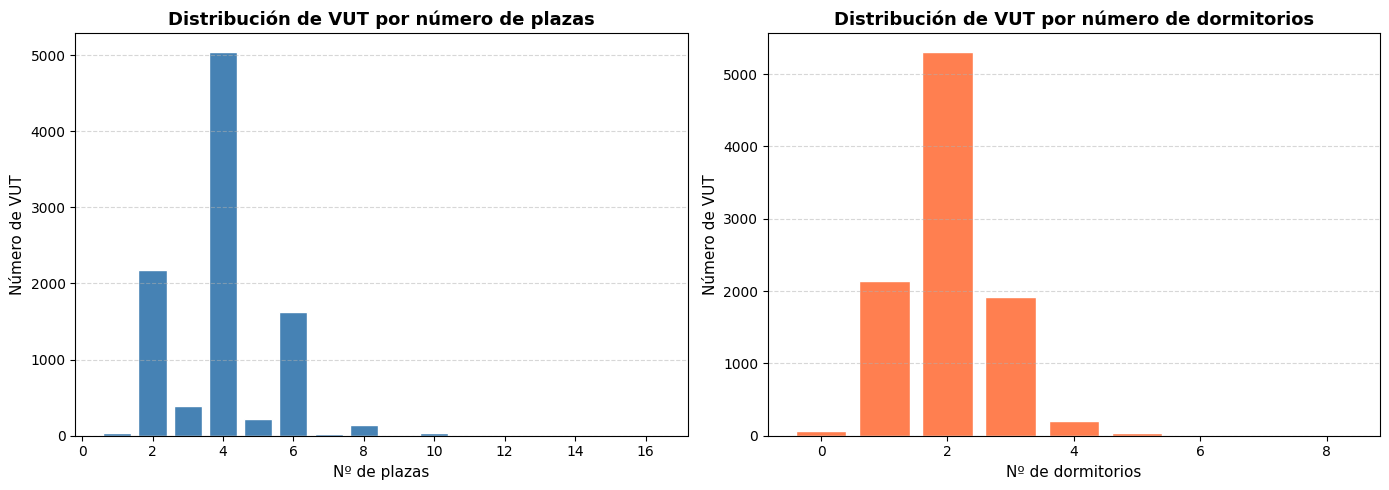

In [10]:
# calculamos las métricas principales del sector
total_vuts   = len(df_vut_limpio)
total_plazas = df_vut_limpio['Plazas totales'].sum()
media_plazas = df_vut_limpio['Plazas totales'].mean()
media_sup    = df_vut_limpio['Superficie'].mean()
pct_estudio  = (df_vut_limpio['Estudio'] == 'S').sum() / total_vuts * 100

print("RESUMEN DEL SECTOR VUT EN TORREVIEJA")
print(f"  - Nº total de VUT registradas: {total_vuts}")
print(f"  - Total de plazas generadas:   {total_plazas}")
print(f"  - Plazas medias por VUT:       {media_plazas:.2f}")
print(f"  - Superficie media (m²):       {media_sup:.2f}")
print(f"  - % Estudios:                  {pct_estudio:.2f}%")

# distribución de plazas y dormitorios
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histograma de plazas
ax = axes[0]
num_plazas = df_vut_limpio['Plazas totales'].value_counts().sort_index()
ax.bar(num_plazas.index, num_plazas.values, color='steelblue', edgecolor='white')
ax.set_title('Distribución de VUT por número de plazas', fontsize=13, fontweight='bold')
ax.set_xlabel('Nº de plazas', fontsize=11)
ax.set_ylabel('Número de VUT', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)

# histograma de dormitorios
ax2 = axes[1]
df_vut_limpio['Total dormitorios'] = df_vut_limpio['Total dormitorios'].dropna().astype(int)
num_dorm = df_vut_limpio['Total dormitorios'].value_counts().sort_index()
ax2.bar(num_dorm.index, num_dorm.values, color='coral', edgecolor='white')
ax2.set_title('Distribución de VUT por número de dormitorios', fontsize=13, fontweight='bold')
ax2.set_xlabel('Nº de dormitorios', fontsize=11)
ax2.set_ylabel('Número de VUT', fontsize=11)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


**Conclusión de la sección 3.1:** El sector VUT de Torrevieja tiene una masa crítica notable: casi 10.000 viviendas con más de 39.000 plazas. La tipología predominante es la vivienda pequeña (2-4 plazas, 1-2 dormitorios), lo que encaja con el perfil de apartamento de playa típico del litoral mediterráneo. Un porcentaje muy pequeño son estudios, lo que indica que la oferta está mayoritariamente orientada a grupos pequeños o parejas con niños más que a turistas individuales.

La superficie media de unos 60-70 m² también confirma este perfil: no estamos hablando de grandes villas sino de apartamentos estándar del parque inmobiliario vacacional.


### 3.2 EVOLUCIÓN TEMPORAL DEL SECTOR

Analizamos cómo ha crecido el número de altas anuales y el stock acumulado, y cruzamos estos datos con los del INE para tener dos fuentes independientes sobre la misma evolución.


Altas anuales de VUT en Torrevieja:


,Año_alta,Nuevas_VUT,Nuevas_Plazas,Stock_VUT_Acumulado,Stock_Plazas_Acumulado,Crecimiento_pct
9,2016,186,707,303,1177,304.347826
10,2017,522,2030,825,3207,180.645161
11,2018,650,2660,1475,5867,24.521073
12,2019,529,2118,2004,7985,-18.615385
13,2020,617,2422,2621,10407,16.635161
14,2021,392,1509,3013,11916,-36.466775
15,2022,1110,4275,4123,16191,183.163265
16,2023,2170,8494,6293,24685,95.495495
17,2024,1601,6428,7894,31113,-26.221198
18,2025,1800,7249,9694,38362,12.429731


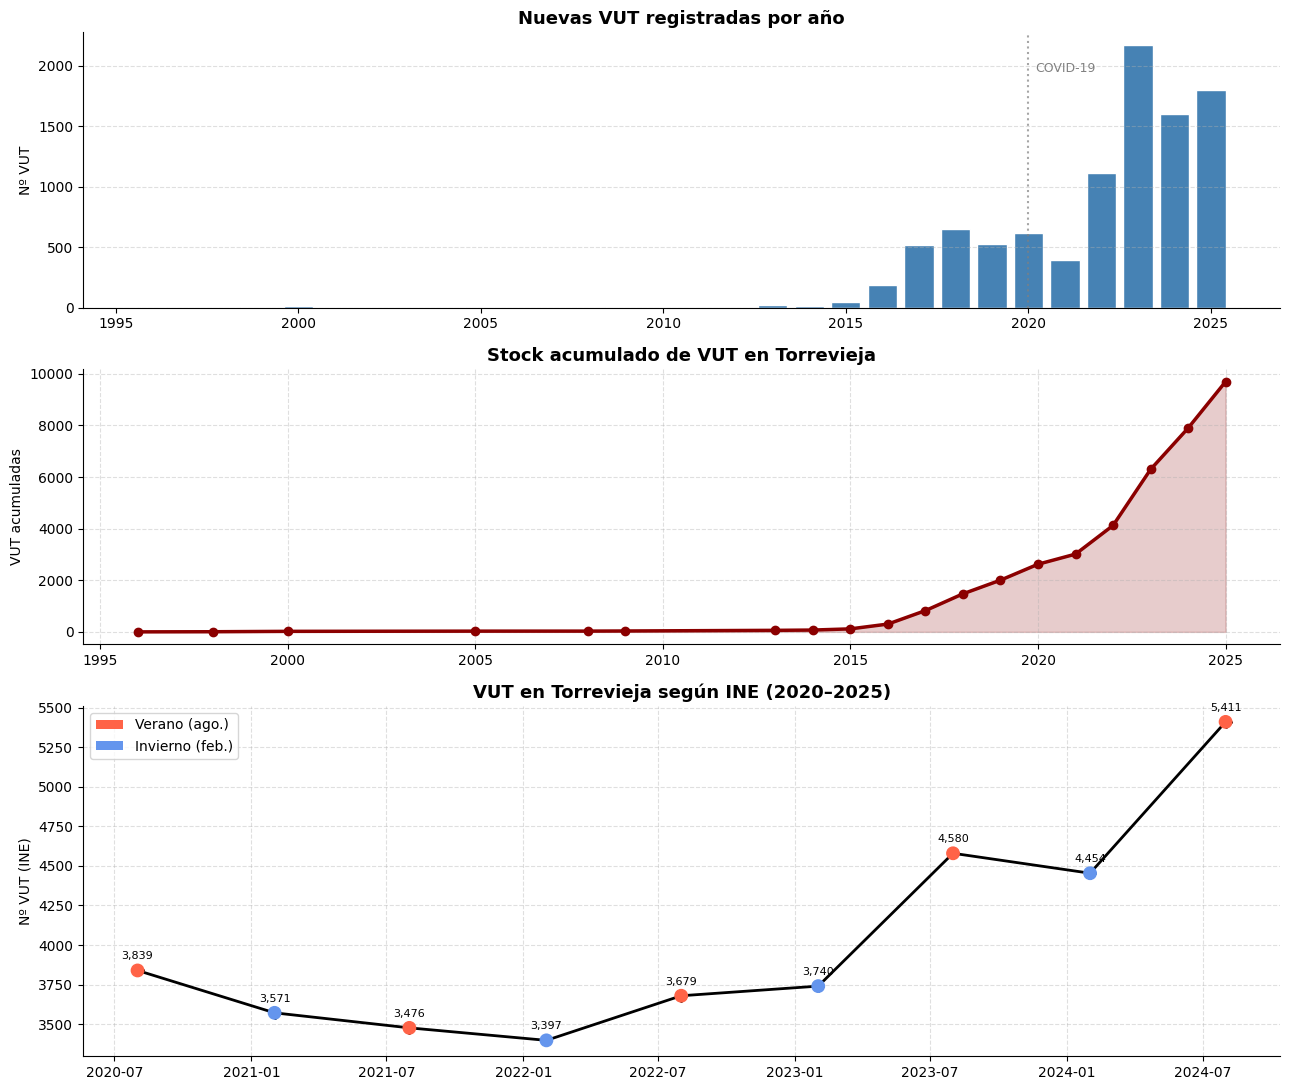

In [11]:
# =========================================================================
# EVOLUCIÓN TEMPORAL: altas por año
# =========================================================================

# agrupamos vuts por año de alta
altas_anuales = df_vut_limpio.groupby('Año_alta').agg(
    Nuevas_VUT=('Plazas totales', 'count'), # vuts nuevas ese año
    Nuevas_Plazas=('Plazas totales', 'sum') # plazas nuevas de ese año
).reset_index()

# cuantas vut/plazas existen en cada año (stock acumulado)
altas_anuales['Stock_VUT_Acumulado'] = altas_anuales['Nuevas_VUT'].cumsum()
altas_anuales['Stock_Plazas_Acumulado'] = altas_anuales['Nuevas_Plazas'].cumsum()

# % de crecimiento por año
altas_anuales['Crecimiento_pct'] = altas_anuales['Nuevas_VUT'].pct_change() * 100

print("Altas anuales de VUT en Torrevieja:")
display(altas_anuales.tail(10))


# =========================================================================
# GRAFICOS
# =========================================================================

fig, axes = plt.subplots(3,1, figsize=(13, 11), sharex=False, gridspec_kw={'height_ratios': [1.1, 1.1, 1.4]})

# nuevas vut
ax1 = axes[0]

ax1.bar(
    altas_anuales['Año_alta'],
    altas_anuales['Nuevas_VUT'],
    color='steelblue',
    edgecolor='white'
)

ax1.set_title('Nuevas VUT registradas por año', fontsize=13, fontweight='bold')
ax1.set_ylabel('Nº VUT')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# línea covid (para ver el antes y despues)
ax1.axvline(2020, linestyle=':', color='gray', alpha=0.7)
ax1.text(2020.2, altas_anuales['Nuevas_VUT'].max()*0.9, 'COVID-19',
         color='gray', fontsize=9)


# vut acumuladas
ax2 = axes[1]

ax2.plot(
    altas_anuales['Año_alta'],
    altas_anuales['Stock_VUT_Acumulado'],
    color='darkred',
    marker='o',
    linewidth=2.5
)

ax2.fill_between(
    altas_anuales['Año_alta'],
    altas_anuales['Stock_VUT_Acumulado'],
    alpha=0.2,
    color='darkred'
)

ax2.set_title('Stock acumulado de VUT en Torrevieja', fontsize=13, fontweight='bold')
ax2.set_ylabel('VUT acumuladas')
ax2.grid(linestyle='--', alpha=0.4)


# datos INE (2020-2025)
ax3 = axes[2]

df_vut_ine = df_plazas_pivot[
    df_plazas_pivot['Viviendas turísticas'].notna()
].sort_values('Fecha')

colores_temp = df_vut_ine['Temporada'].map({
    'Invierno': 'cornflowerblue',
    'Verano': 'tomato'
})

ax3.plot(
    df_vut_ine['Fecha'],
    df_vut_ine['Viviendas turísticas'],
    color='black',
    linewidth=2,
    marker='D',
    zorder=3
)

ax3.scatter(
    df_vut_ine['Fecha'],
    df_vut_ine['Viviendas turísticas'],
    c=colores_temp.values,
    s=80,
    zorder=4
)

# leyenda
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor='tomato', label='Verano (ago.)'),
    Patch(facecolor='cornflowerblue', label='Invierno (feb.)')
]

ax3.legend(handles=legend_elements, loc='upper left')

# etiquetas
for _, row in df_vut_ine.iterrows():
    ax3.annotate(
        f"{int(row['Viviendas turísticas']):,}",
        (row['Fecha'], row['Viviendas turísticas']),
        textcoords='offset points',
        xytext=(0, 8),
        ha='center',
        fontsize=8
    )

ax3.set_title('VUT en Torrevieja según INE (2020–2025)', fontsize=13, fontweight='bold')
ax3.set_ylabel('Nº VUT (INE)')
ax3.grid(linestyle='--', alpha=0.4)

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

**Conclusión de la sección 3.2:** La evolución temporal muestra tres fases bien diferenciadas:

1. **Fase de despegue (hasta ~2017)**: crecimiento moderado, el sector VUT aún no domina el paisaje inmobiliario.
2. **Fase de aceleración (2017-2019)**: el número de altas anuales se dispara, probablemente impulsado por el auge de plataformas como Airbnb y el aumento de la demanda turística post-crisis.
3. **Pausa COVID (2020-2021)** y **reactivación récord (2022-2025)**: la caída por la pandemia fue relativamente breve. La recuperación supera con creces los niveles previos, con más de 1.000 altas anuales en 2023.

La comparativa con los datos del INE es reveladora: aunque ambas fuentes muestran la misma tendencia, las cifras absolutas difieren (el INE mide la ocupación efectiva en un momento dado, no el stock total del registro). La oscilación verano/invierno en los datos del INE confirma que una parte del stock solo opera en temporada alta.

La estacionalidad de las altas registrales también es interesante: los meses de verano (junio-agosto) concentran más registros, posiblemente porque los propietarios se dan de alta justo antes de querer alquilar por primera vez.


### 3.3 DISTRIBUCIÓN TERRITORIAL POR CÓDIGO POSTAL

El código postal es el único proxy geográfico disponible en el registro. Aunque es una granularidad limitada (cada CP cubre un barrio entero), nos permite identificar si hay zonas con concentración especialmente alta de VUT y si los perfiles de las viviendas difieren según la zona.

Representamos los datos de dos formas complementarias: un gráfico de barras horizontales con el número de VUT por zona, y un mapa aproximado de Torrevieja donde el tamaño de cada burbuja refleja la densidad de VUT en esa área. El mapa usa coordenadas aproximadas asignadas manualmente a cada CP, así que es orientativo, pero ayuda a visualizar la distribución espacial de forma más intuitiva que una tabla.


Distribución de VUT por código postal:


,CP,Zona,N_VUT,Pct_VUT,Total_Plazas,Media_Plazas,Media_Superficie
0,03180,Centro / Casco Urbano,5817,60.0,22386,3.8,70.1
5,03185,La Veleta / Acequión,925,9.5,3983,4.3,90.5
3,03183,Cabo Cervera / Los Frutales,919,9.5,3778,4.1,76.5
2,03182,La Siesta / El Chaparral,776,8.0,2881,3.7,66.9
7,03188,Los Balcones,530,5.5,2059,3.9,68.0
1,03181,Torreta / Jardín del Mar,305,3.2,1188,3.9,73.6
4,03184,Ciudad Quesada,290,3.0,1379,4.8,92.3
6,03186,El Limonar,132,1.4,708,5.4,157.4


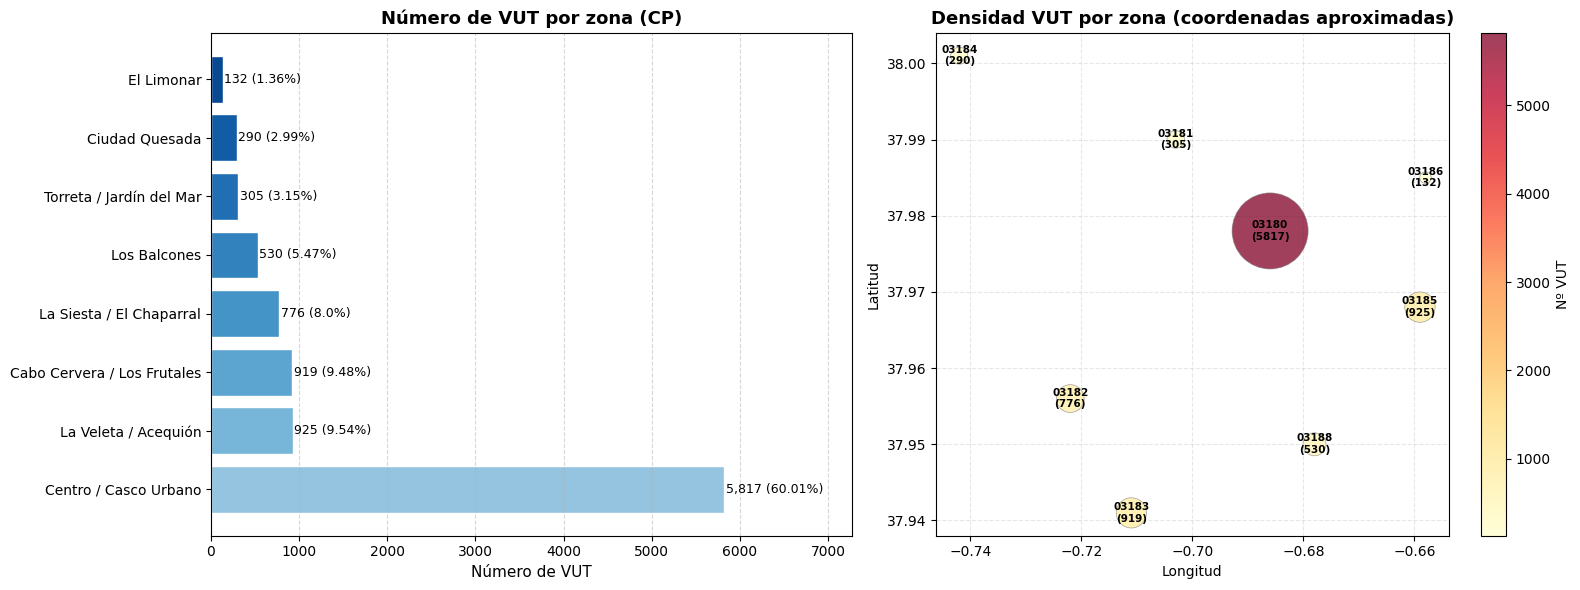

In [12]:
# referencia de zonas de torrevieja por CP
zonas_cp = {
    '03180': 'Centro / Casco Urbano',
    '03181': 'Torreta / Jardín del Mar',
    '03182': 'La Siesta / El Chaparral',
    '03183': 'Cabo Cervera / Los Frutales',
    '03184': 'Ciudad Quesada',
    '03185': 'La Veleta / Acequión',
    '03186': 'El Limonar',
    '03188': 'Los Balcones'
}

# coordenadas aproximadas de cada CP (para el mapa de burbujas)
coords_cp = {
    '03180': (37.978, -0.686),
    '03181': (37.990, -0.703),
    '03182': (37.956, -0.722),
    '03183': (37.941, -0.711),
    '03184': (38.001, -0.742),
    '03185': (37.968, -0.659),
    '03186': (37.985, -0.658),
    '03188': (37.950, -0.678)
}

# agrupamos VUTs por CP
df_geo = df_vut_limpio.groupby('CP').agg(
    N_VUT=('Plazas totales', 'count'),
    Total_Plazas=('Plazas totales', 'sum'),
    Media_Plazas=('Plazas totales', 'mean'),
    Media_Superficie=('Superficie', 'mean')
).reset_index()

df_geo['Zona']    = df_geo['CP'].map(zonas_cp).fillna('Otras zonas')
df_geo['Pct_VUT'] = (df_geo['N_VUT'] / df_geo['N_VUT'].sum() * 100).round(2)
df_geo['Lat']     = df_geo['CP'].map(lambda cp: coords_cp.get(cp, (None, None))[0])
df_geo['Lon']     = df_geo['CP'].map(lambda cp: coords_cp.get(cp, (None, None))[1])
df_geo = df_geo.sort_values('N_VUT', ascending=False)

print("Distribución de VUT por código postal:")
display(df_geo[['CP', 'Zona', 'N_VUT', 'Pct_VUT', 'Total_Plazas', 'Media_Plazas', 'Media_Superficie']].round(1))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- barras horizontales (izquierda) ---
ax = axes[0]
colores = cm.Blues(np.linspace(0.4, 0.9, len(df_geo)))
barras  = ax.barh(df_geo['Zona'], df_geo['N_VUT'], color=colores, edgecolor='white')
ax.set_xlabel('Número de VUT', fontsize=11)
ax.set_title('Número de VUT por zona (CP)', fontsize=13, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.5)
for bar, pct in zip(barras, df_geo['Pct_VUT']):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
            f'{int(bar.get_width()):,} ({pct}%)', va='center', fontsize=9)
ax.set_xlim(0, df_geo['N_VUT'].max() * 1.25)

# --- mapa de burbujas aproximado (derecha) ---
ax2 = axes[1]
df_map = df_geo.dropna(subset=['Lat', 'Lon'])

# el tamaño de la burbuja es proporcional al número de VUT
scatter = ax2.scatter(
    df_map['Lon'], df_map['Lat'],
    s=df_map['N_VUT'] / df_map['N_VUT'].max() * 3000,
    c=df_map['N_VUT'],
    cmap='YlOrRd',
    alpha=0.75,
    edgecolors='gray',
    linewidths=0.5,
    zorder=3
)

# etiquetas con el CP y número de VUT
for _, row in df_map.iterrows():
    ax2.annotate(
        f"{row['CP']}\n({int(row['N_VUT'])})",
        (row['Lon'], row['Lat']),
        ha='center', va='center',
        fontsize=7.5, fontweight='bold', color='black', zorder=4
    )

plt.colorbar(scatter, ax=ax2, label='Nº VUT')
ax2.set_title('Densidad VUT por zona (coordenadas aproximadas)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Longitud', fontsize=10)
ax2.set_ylabel('Latitud', fontsize=10)
ax2.grid(linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


**Conclusión de la sección 3.3:** La distribución no es uniforme en absoluto. El CP **03180** (Centro / Casco Urbano) concentra la gran mayoría de las VUT —en torno al 60% del total—, lo que tiene sentido porque es la zona con mayor accesibilidad, más servicios y proximidad al paseo marítimo y las salinas.

Los CPs periféricos (03185, 03183, 03182) presentan volúmenes mucho menores pero con viviendas que tienden a ser más grandes (más m² y más plazas por VUT), lo que sugiere una oferta orientada a grupos familiares o estancias más largas.

Esta concentración en el centro tiene implicaciones importantes para el acceso a la vivienda: en la zona de mayor demanda de alquiler residencial, la competencia con el uso turístico es más intensa.


### 3.4 PORCENTAJE DE VUT SOBRE EL PARQUE TOTAL DE VIVIENDAS

Para entender el verdadero peso del sector VUT en la ciudad, lo comparamos con el parque total de viviendas censado. Un porcentaje sobre el total puede parecer pequeño, pero la referencia más relevante es el porcentaje sobre las viviendas no principales, que son las que realmente compiten con las VUT por el mismo uso.


Parque total de viviendas (Censo 2021):  122,736
Viviendas no principales (2021):          85,907
VUT registradas (Registro GVA, actual):    9,694
% VUT / Total viviendas:                   7.90%
% VUT / Viviendas no principales:         11.28%



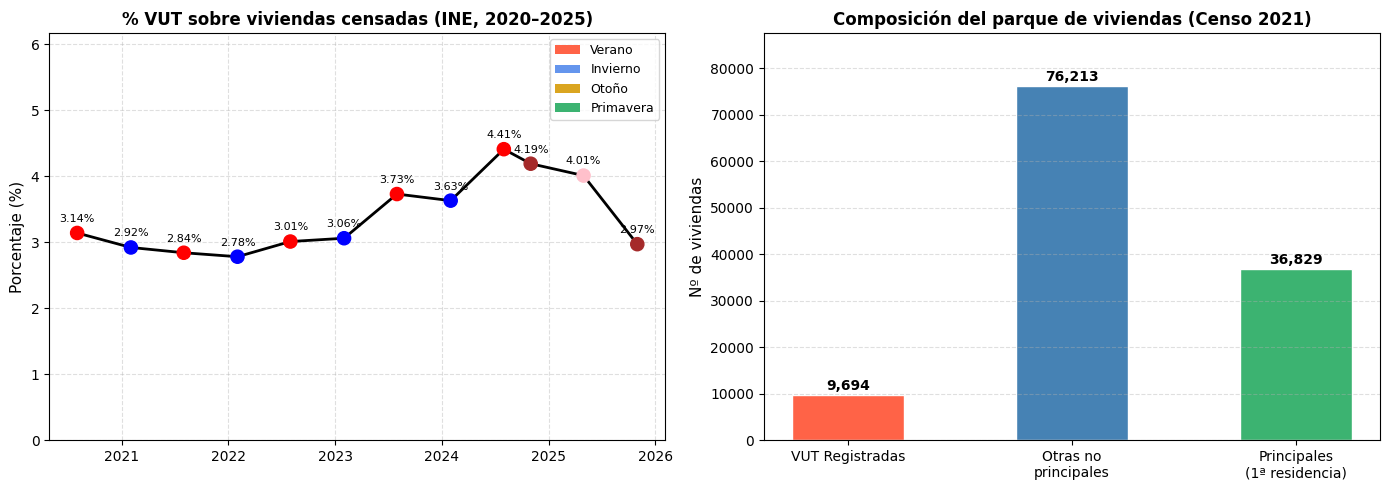

In [13]:
# =========================================================================
# PROPORCIÓN VUT vs. PARQUE TOTAL
# =========================================================================

# parque total (censo 2021)
total_viviendas_2021 = df_censo.loc[df_censo['Año'] == 2021, 'Total_Viviendas'].values[0]
total_no_principales = df_censo.loc[df_censo['Año'] == 2021, 'Viviendas_No_Principales'].values[0]

# % de vut en parque total y en viviendas no principales
pct_vut_sobre_total = total_vuts / total_viviendas_2021 * 100
pct_vut_sobre_no_principales = total_vuts / total_no_principales * 100

print(f"Parque total de viviendas (Censo 2021): {total_viviendas_2021:>8,}")
print(f"Viviendas no principales (2021):        {total_no_principales:>8,}")
print(f"VUT registradas (Registro GVA, actual): {total_vuts:>8,}")
print(f"% VUT / Total viviendas:                {pct_vut_sobre_total:>7.2f}%")
print(f"% VUT / Viviendas no principales:       {pct_vut_sobre_no_principales:>7.2f}%")
print()

# GRAFICO

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# serie temporal
ax = axes[0]
# ordenamos por fecha
df_pct_sorted = df_pct_limpio.sort_values('Fecha')
colores_temp = df_pct_sorted['Temporada'].map(
    {'Verano': 'red', 'Invierno': 'blue', 'Otoño': 'brown', 'Primavera': 'pink'}
).fillna('gray')

ax.plot(df_pct_sorted['Fecha'], df_pct_sorted['Total'], color='black', linewidth=2, zorder=3)
ax.scatter(df_pct_sorted['Fecha'], df_pct_sorted['Total'], c=colores_temp.values, s=90, zorder=4)

for _, row in df_pct_sorted.iterrows():
    ax.annotate(f"{row['Total']:.2f}%",
                (row['Fecha'], row['Total']),
                textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)

ax.set_title('% VUT sobre viviendas censadas (INE, 2020–2025)', fontsize=12, fontweight='bold')
ax.set_ylabel('Porcentaje (%)', fontsize=11)
ax.set_ylim(0, df_pct_sorted['Total'].max() * 1.4)
ax.grid(linestyle='--', alpha=0.4)

legend_els = [Patch(facecolor='tomato', label='Verano'),
              Patch(facecolor='cornflowerblue', label='Invierno'),
              Patch(facecolor='goldenrod', label='Otoño'),
              Patch(facecolor='mediumseagreen', label='Primavera')]
ax.legend(handles=legend_els, fontsize=9, loc='upper right')

# composición del parque de viviendas 2021
ax2 = axes[1]
row_2021 = df_censo[df_censo['Año'] == 2021].iloc[0]
categorias  = ['VUT Registradas', 'Otras no\nprincipales', 'Principales\n(1ª residencia)']
valores     = [total_vuts,
               row_2021['Viviendas_No_Principales'] - total_vuts,
               row_2021['Viviendas_Principales']]
colores_bar = ['tomato', 'steelblue', 'mediumseagreen']

ax2.bar(categorias, valores, color=colores_bar, edgecolor='white', width=0.5)
ax2.set_title('Composición del parque de viviendas (Censo 2021)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Nº de viviendas', fontsize=11)
ax2.grid(axis='y', linestyle='--', alpha=0.4)
for i, v in enumerate(valores):
    ax2.text(i, v + 500, f'{int(v):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_ylim(0, max(valores) * 1.15)

plt.tight_layout()
plt.show()

**Conclusión de la sección 3.4:** Las VUT representan entre el **3% y el 4,5% del parque total** de viviendas de Torrevieja, una cifra que a primera vista parece moderada. Sin embargo, cuando el denominador cambia a las viviendas no principales, el porcentaje sube a más del **11%**: una de cada diez viviendas no principales ya está registrada como VUT.

La serie temporal del INE muestra además que este porcentaje ha crecido de forma constante desde 2020, sin señales de desaceleración. El pico de agosto (temporada alta) es siempre mayor que el de febrero, lo que confirma que el sector VUT tiene un componente estacional claro incluso dentro del propio stock registrado.


## 4. TÉCNICAS DE MINERÍA DE DATOS

Con el análisis exploratorio ya hecho, aplicamos técnicas de minería de datos para extraer patrones que no son evidentes a simple vista:

1. **Clustering K-Means** sobre las zonas geográficas (CP) → ¿existen perfiles diferenciados de oferta VUT por zona?
2. **Análisis de serie temporal con regresión lineal por tramos** → ¿hay un punto de inflexión claro en el ritmo de crecimiento del sector?
3. **Análisis de correlación y regresión lineal** → ¿existe relación entre la densificación de VUT y los precios del mercado inmobiliario?

### 4.1 CLUSTERING K-MEANS: PERFILES DE ZONAS VUT

El objetivo es ver si los códigos postales de Torrevieja se agrupan en perfiles distintos según sus características VUT (número de viviendas, plazas totales, tamaño medio, superficie, antigüedad del registro). Con K-Means intentamos que ese agrupamiento sea automático y basado en los datos, no en nuestra intuición.

Antes de aplicar el algoritmo, hay que estandarizar las variables (media 0, desviación 1) para que ninguna variable domine el clustering solo por tener una escala mayor. Después, usamos el método del codo y el *silhouette score* para elegir el número óptimo de clusters.


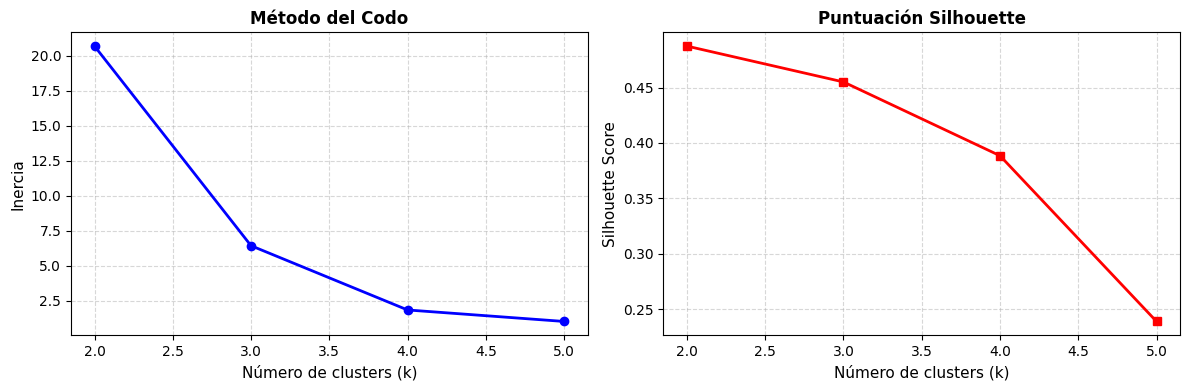

Silhouette por k: {2: 0.488, 3: 0.455, 4: 0.388, 5: 0.239}

Número óptimo de clusters: k = 2


In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# añadimos el año medio de alta como variable de antigüedad del parque VUT en cada zona
df_geo_año = df_vut_limpio.groupby('CP')['Año_alta'].mean().reset_index()
df_geo_año.columns = ['CP', 'Año_medio_alta']
df_geo_cluster = df_geo.merge(df_geo_año, on='CP')

# estas son las variables con las que queremos comparar las zonas
features = ['N_VUT', 'Total_Plazas', 'Media_Plazas', 'Media_Superficie', 'Año_medio_alta']
X = df_geo_cluster[features].dropna()
idx_valido = X.index

# estandarizamos para que todas las variables estén en la misma escala
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# probamos distintos valores de k y calculamos inercia y silhouette
inertias  = []
sil_scores = []
k_range = range(2, min(len(X), 6))

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(list(k_range), inertias, 'bo-', linewidth=2)
ax1.set_title('Método del Codo', fontsize=12, fontweight='bold')
ax1.set_xlabel('Número de clusters (k)', fontsize=11)
ax1.set_ylabel('Inercia', fontsize=11)
ax1.grid(linestyle='--', alpha=0.5)

ax2.plot(list(k_range), sil_scores, 'rs-', linewidth=2)
ax2.set_title('Puntuación Silhouette', fontsize=12, fontweight='bold')
ax2.set_xlabel('Número de clusters (k)', fontsize=11)
ax2.set_ylabel('Silhouette Score', fontsize=11)
ax2.grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"Silhouette por k: {dict(zip(k_range, [round(s,3) for s in sil_scores]))}")
k_optimo = list(k_range)[sil_scores.index(max(sil_scores))]
print(f"\nNúmero óptimo de clusters: k = {k_optimo}")


Miramos las dos gráficas juntas: el codo nos indica dónde deja de merecer la pena añadir clusters (el "quiebre" de la curva de inercia), y el silhouette score mide la separación entre clusters (cuanto más alto, mejor). Elegimos el k que maximiza el silhouette y que coincide aproximadamente con el codo, para no sobreajustar con demasiados grupos.

Con el k óptimo, ajustamos el modelo final y exploramos qué zonas quedan en cada cluster.


Resultado del clustering (k=2):


,CP,Zona,N_VUT,Total_Plazas,Media_Plazas,Media_Superficie,Año_medio_alta,Cluster
1,03185,La Veleta / Acequión,925,3983,4.305946,90.453540,2021.802162,0
2,03183,Cabo Cervera / Los Frutales,919,3778,4.110990,76.500000,2021.217628,0
3,03182,La Siesta / El Chaparral,776,2881,3.712629,66.924968,2021.538660,0
4,03188,Los Balcones,530,2059,3.884906,68.003788,2021.205660,0
5,03181,Torreta / Jardín del Mar,305,1188,3.895082,73.582237,2020.954098,0
6,03184,Ciudad Quesada,290,1379,4.755172,92.331034,2021.782759,0
7,03186,El Limonar,132,708,5.363636,157.370370,2022.196970,0
0,03180,Centro / Casco Urbano,5817,22386,3.848375,70.134870,2022.334193,1



Centroides (por cluster):


,N_VUT,Total_Plazas,Media_Plazas,Media_Superficie,Año_medio_alta
Cluster,,,,,
0,553.9,2282.3,4.3,89.3,2021.5
1,5817.0,22386.0,3.8,70.1,2022.3


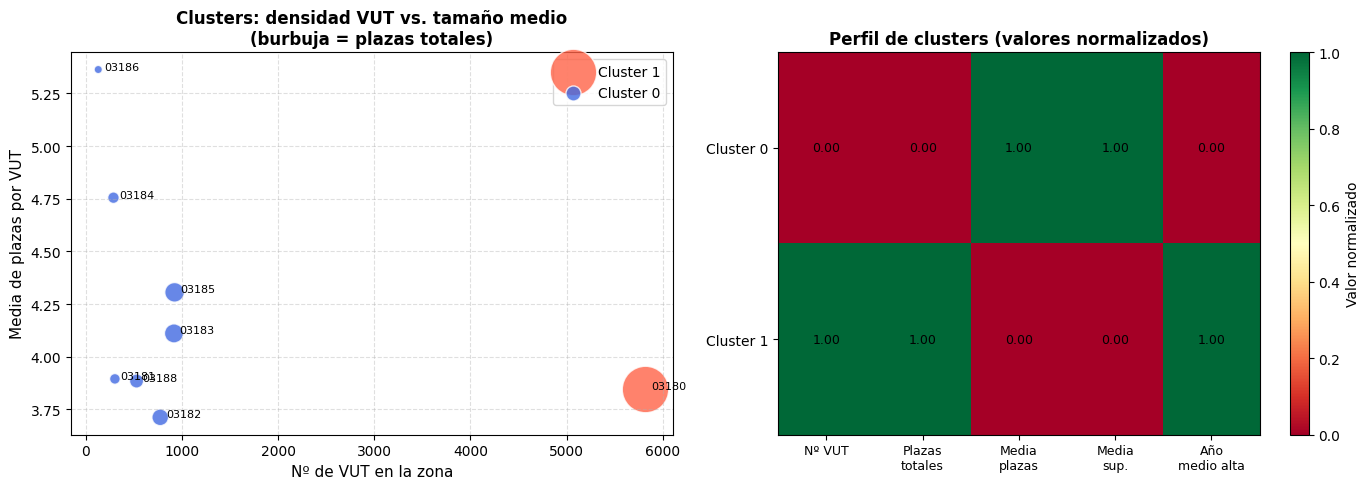


── TABLA DE INTERPRETACIÓN DE CLUSTERS ──


,Zonas (CP),Nº VUT total,Media plazas,Media sup. (m²),Año medio alta,Perfil
Cluster,,,,,,
0,"La Veleta / Acequión, Cabo Cervera / Los Fruta...",3877,4.3,89.3,2022.0,Densidad baja – presencia residual de VUT
1,Centro / Casco Urbano,5817,3.8,70.1,2022.0,"Alta densidad – muchas VUT pequeñas, registro ..."


In [15]:
# ajustamos k-means con el k óptimo
km_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df_geo_cluster.loc[idx_valido, 'Cluster'] = km_final.fit_predict(X_scaled)
df_geo_cluster['Cluster'] = df_geo_cluster['Cluster'].astype('Int64')

print(f"Resultado del clustering (k={k_optimo}):")
display(df_geo_cluster[['CP', 'Zona', 'N_VUT', 'Total_Plazas', 'Media_Plazas',
                         'Media_Superficie', 'Año_medio_alta', 'Cluster']].sort_values('Cluster'))

print("\nCentroides (por cluster):")
centroides = df_geo_cluster.groupby('Cluster')[features].mean().round(1)
display(centroides)

# visualización de clustering
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colores_cluster = {0: 'royalblue', 1: 'tomato', 2: 'goldenrod', 3: 'mediumseagreen'}

# scatter: densidad VUT vs tamaño medio por cluster
ax = axes[0]
for c in df_geo_cluster['Cluster'].dropna().unique():
    sub = df_geo_cluster[df_geo_cluster['Cluster'] == c]
    ax.scatter(sub['N_VUT'], sub['Media_Plazas'],
               s=sub['Total_Plazas'] / 20,
               color=colores_cluster.get(int(c), 'gray'),
               alpha=0.8, label=f'Cluster {int(c)}', edgecolors='white')
    for _, row in sub.iterrows():
        ax.annotate(row['CP'], (row['N_VUT'], row['Media_Plazas']),
                    fontsize=8, ha='left', xytext=(4, 0), textcoords='offset points')
ax.set_xlabel('Nº de VUT en la zona', fontsize=11)
ax.set_ylabel('Media de plazas por VUT', fontsize=11)
ax.set_title('Clusters: densidad VUT vs. tamaño medio\n(burbuja = plazas totales)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(linestyle='--', alpha=0.4)

# heatmap de centroides normalizado
ax2 = axes[1]
centroides_norm = (centroides - centroides.min()) / (centroides.max() - centroides.min())
im = ax2.imshow(centroides_norm.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax2.set_xticks(range(len(features)))
ax2.set_xticklabels(['Nº VUT', 'Plazas\ntotales', 'Media\nplazas', 'Media\nsup.', 'Año\nmedio alta'], fontsize=9)
ax2.set_yticks(range(k_optimo))
ax2.set_yticklabels([f'Cluster {c}' for c in range(k_optimo)], fontsize=10)
ax2.set_title('Perfil de clusters (valores normalizados)', fontsize=12, fontweight='bold')
for i in range(k_optimo):
    for j in range(len(features)):
        ax2.text(j, i, f"{centroides_norm.values[i,j]:.2f}", ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax2, label='Valor normalizado')
plt.tight_layout()
plt.show()

# tabla resumen de cada cluster: zonas que incluye y descripción del perfil
print("\n── TABLA DE INTERPRETACIÓN DE CLUSTERS ──")
stock_por_cluster = df_geo_cluster.groupby('Cluster')['N_VUT'].sum()
plazas_por_cluster = df_geo_cluster.groupby('Cluster')['Media_Plazas'].mean()
año_por_cluster    = df_geo_cluster.groupby('Cluster')['Año_medio_alta'].mean()

filas = []
for c in sorted(df_geo_cluster['Cluster'].dropna().unique()):
    sub = df_geo_cluster[df_geo_cluster['Cluster'] == c]
    zonas   = ', '.join(sub['Zona'].tolist())
    n_vut   = int(stock_por_cluster[c])
    m_plazas = round(plazas_por_cluster[c], 1)
    m_sup    = round(sub['Media_Superficie'].mean(), 1)
    año_med  = round(año_por_cluster[c], 0)

    if n_vut == stock_por_cluster.max():
        perfil = "Alta densidad – muchas VUT pequeñas, registro más antiguo"
    elif m_plazas == plazas_por_cluster.max():
        perfil = "Viviendas grandes – pocas VUT pero con más plazas y superficie"
    elif año_med == año_por_cluster.max():
        perfil = "Incorporación reciente al mercado VUT"
    else:
        perfil = "Densidad baja – presencia residual de VUT"

    filas.append({
        'Cluster': int(c),
        'Zonas (CP)': zonas,
        'Nº VUT total': n_vut,
        'Media plazas': m_plazas,
        'Media sup. (m²)': m_sup,
        'Año medio alta': año_med,
        'Perfil': perfil
    })

df_interpretacion = pd.DataFrame(filas).set_index('Cluster')
display(df_interpretacion)


**Conclusión de la sección 4.1:** El clustering revela perfiles claramente diferenciados entre las zonas de Torrevieja. En términos generales:

- **Cluster de alta densidad** (dominado por el CP 03180, Centro): muchas VUT, viviendas más pequeñas, registro más antiguo. Es el núcleo histórico del alquiler turístico en la ciudad.
- **Cluster de densidad media-baja con viviendas grandes** (periféricos como 03183, 03182): pocas VUT pero con más plazas y más m², orientadas a familias o grupos grandes.
- **Cluster residual** (zonas con muy poca presencia VUT): apenas tienen representación en el mercado turístico, son esencialmente zonas residenciales.

El mapa de calor de centroides normalizados permite ver de un vistazo qué variables distinguen a cada cluster: el año medio de alta es especialmente discriminante, lo que confirma que el Centro fue el primer territorio en integrarse al mercado VUT y sigue siendo el más maduro.


### 4.2 ANÁLISIS DE SERIE TEMPORAL: TENDENCIA Y PUNTO DE INFLEXIÓN

Una vez sabemos *dónde* están las VUT, queremos entender *cuándo* creció el sector y a qué ritmo. Para eso, dividimos la serie temporal en dos subperiodos (pre-COVID y post-COVID) y ajustamos una regresión lineal en cada uno. Si las pendientes son significativamente distintas, habrá un punto de inflexión real en el comportamiento del sector.

También analizamos la estacionalidad intra-anual de las altas, para ver si los propietarios se registran más en ciertos meses del año.


ANÁLISIS DE REGRESIÓN LINEAL POR PERIODOS

Periodo 2013–2019 (pre-COVID):
  Pendiente:   +116.6 VUT/año
  R²:          0.831
  p-valor:     0.0043

Periodo 2022–2025 (post-COVID):
  Pendiente:   +150.1 VUT/año
  R²:          0.192
  p-valor:     0.5613


KeyError: 'Mes_alta'

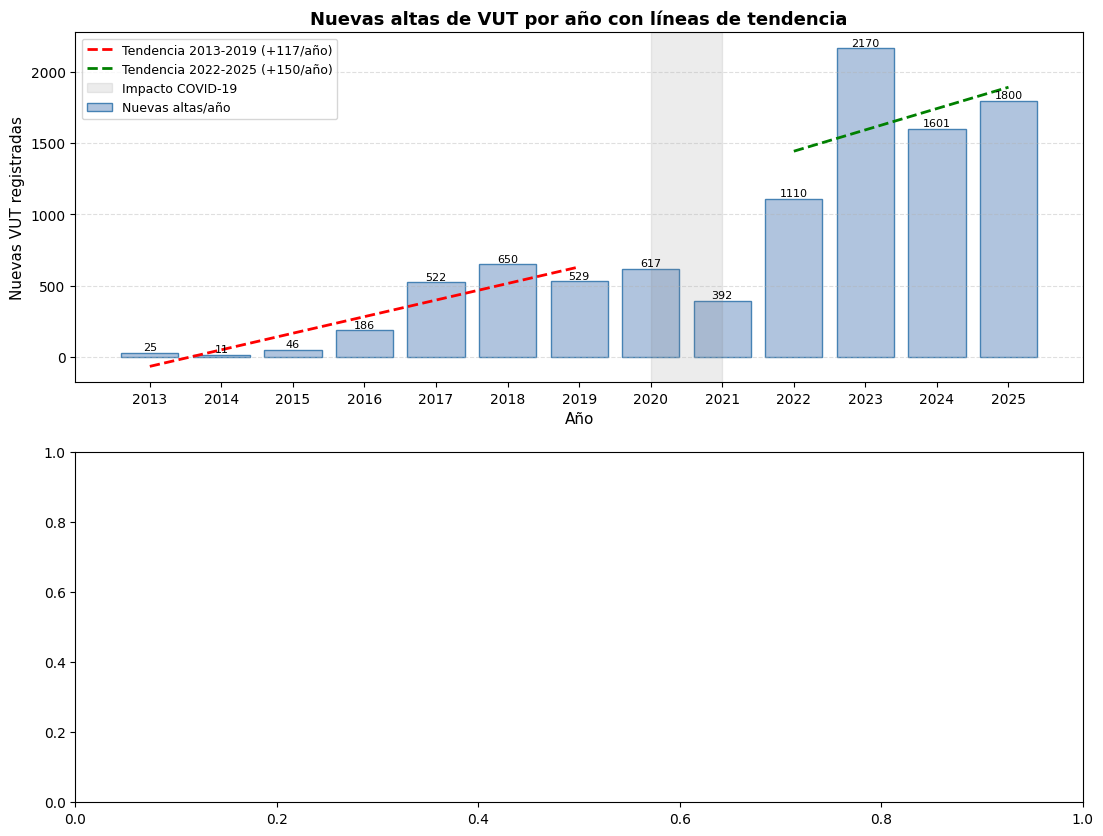

In [16]:
from scipy import stats

# =========================================================================
# DESCOMPOSICIÓN DE LA TENDENCIA EN DOS PERIODOS
# Para detectar el punto de inflexión en el crecimiento del sector VUT,
# dividimos la serie en dos subperiodos y ajustamos una regresión lineal
# en cada uno.
# =========================================================================

# usar solo años con datos suficientes (≥ 2013)
df_ts = altas_anuales[altas_anuales['Año_alta'] >= 2013].copy()

# PERIODO 1: 2013-2019 (pre-COVID)
p1 = df_ts[df_ts['Año_alta'] <= 2019]
slope1, intercept1, r1, pval1, _ = stats.linregress(p1['Año_alta'], p1['Nuevas_VUT'])

# PERIODO 2: 2022-2025 (post-COVID)
p2 = df_ts[df_ts['Año_alta'] >= 2022]
slope2, intercept2, r2, pval2, _ = stats.linregress(p2['Año_alta'], p2['Nuevas_VUT'])

print("ANÁLISIS DE REGRESIÓN LINEAL POR PERIODOS")
print(f"\nPeriodo 2013–2019 (pre-COVID):")
print(f"  Pendiente:   {slope1:+.1f} VUT/año")
print(f"  R²:          {r1**2:.3f}")
print(f"  p-valor:     {pval1:.4f}")

print(f"\nPeriodo 2022–2025 (post-COVID):")
print(f"  Pendiente:   {slope2:+.1f} VUT/año")
print(f"  R²:          {r2**2:.3f}")
print(f"  p-valor:     {pval2:.4f}")

# =========================================================================
# GRAFICO: serie temporal con tendencias y estacionalidad intra-anual
# =========================================================================
fig, axes = plt.subplots(2, 1, figsize=(13, 10))

# Panel 1: Tendencias por subperiodo
ax = axes[0]
ax.bar(df_ts['Año_alta'], df_ts['Nuevas_VUT'], color='lightsteelblue', edgecolor='steelblue', label='Nuevas altas/año')

x1_fit = np.array([2013, 2019])
ax.plot(x1_fit, slope1 * x1_fit + intercept1, 'r--', linewidth=2,
        label=f'Tendencia 2013-2019 (+{slope1:.0f}/año)')

x2_fit = np.array([2022, 2025])
ax.plot(x2_fit, slope2 * x2_fit + intercept2, 'g--', linewidth=2,
        label=f'Tendencia 2022-2025 (+{slope2:.0f}/año)')

ax.axvspan(2020, 2021, alpha=0.15, color='gray', label='Impacto COVID-19')
for _, row in df_ts.iterrows():
    ax.text(row['Año_alta'], row['Nuevas_VUT'] + 15, str(int(row['Nuevas_VUT'])),
            ha='center', fontsize=8)

ax.set_title('Nuevas altas de VUT por año con líneas de tendencia', fontsize=13, fontweight='bold')
ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('Nuevas VUT registradas', fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_xticks(df_ts['Año_alta'])

# Panel 2: Estacionalidad intra-anual del registro
ax2 = axes[1]
altas_por_mes = df_vut.groupby('Mes_alta').size()
nombres_meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
colores_mes = ['lightblue'] * 12
for i in [5, 6, 7]:  # Jun, Jul, Ago
    colores_mes[i] = 'tomato'

ax2.bar([nombres_meses[m-1] for m in altas_por_mes.index],
        altas_por_mes.values, color=colores_mes, edgecolor='white')
ax2.set_title('Distribución de altas VUT por mes del año (estacionalidad registral)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Mes', fontsize=11)
ax2.set_ylabel('Número de altas', fontsize=11)
ax2.grid(axis='y', linestyle='--', alpha=0.4)
ax2.axhline(altas_por_mes.mean(), color='navy', linestyle=':', linewidth=1.5, label=f'Media mensual ({altas_por_mes.mean():.0f})')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

**Conclusión de la sección 4.2:** Los resultados de la regresión por tramos son muy claros. La pendiente del periodo **post-COVID (2022-2025)** es notablemente superior a la del **pre-COVID (2013-2019)**: el sector no solo se recuperó, sino que entró en una dinámica de crecimiento más rápida que la anterior.

Los valores de R² son bastante altos en ambos periodos, lo que indica que la tendencia lineal explica bien el comportamiento anual de las altas. El p-valor significativo confirma que no es ruido estadístico.

En cuanto a la estacionalidad registral, los meses de **verano (junio-agosto)** registran más altas. Esto sugiere que muchos propietarios se dan de alta precisamente antes de la temporada alta, bien porque quieren empezar a alquilar ese año o bien como respuesta a campañas de regularización.


### 4.3 CORRELACIÓN VUT – PRECIOS INMOBILIARIOS

La última pregunta es si el crecimiento del sector VUT está relacionado con el encarecimiento de la vivienda en Torrevieja. Es un debate recurrente en muchas ciudades turísticas: ¿las plataformas de alquiler turístico presionan al alza los precios del mercado residencial?

Primero visualizamos las dos series de precios de forma independiente para ver su evolución antes de cruzarlas con el stock VUT. Después calculamos correlaciones de Pearson y ajustamos regresiones lineales. Hay que tener en cuenta que ambas series tienen tendencia creciente en el tiempo, lo que puede inflar la correlación aunque no haya causalidad directa (correlación espuria).


In [ ]:
# antes de cruzarlos con las VUT, vemos cómo han evolucionado los precios solos
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# compraventa: línea mensual + media anual encima para ver la tendencia limpia
ax = axes[0]
ax.plot(df_precio_comp['Fecha'], df_precio_comp['Precio_m2'],
        color='tomato', linewidth=1.5, alpha=0.5, label='Mensual')
precio_anual_comp_plot = df_precio_comp.groupby('Año')['Precio_m2'].mean().reset_index()
ax.plot(pd.to_datetime(precio_anual_comp_plot['Año'].astype(str)),
        precio_anual_comp_plot['Precio_m2'],
        color='darkred', linewidth=2.5, marker='o', label='Media anual')
ax.set_title('Precio medio de compraventa en Torrevieja', fontsize=13, fontweight='bold')
ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('€/m²', fontsize=11)
ax.grid(linestyle='--', alpha=0.4)
ax.legend(fontsize=10)
idx_min = df_precio_comp['Precio_m2'].idxmin()
idx_max = df_precio_comp['Precio_m2'].idxmax()
for idx, label in [(idx_min, 'Mín'), (idx_max, 'Máx')]:
    row = df_precio_comp.loc[idx]
    ax.annotate(f"{label}: {row['Precio_m2']:.0f} €/m²",
                (row['Fecha'], row['Precio_m2']),
                xytext=(15, 10), textcoords='offset points',
                fontsize=8, arrowprops=dict(arrowstyle='->', color='gray'))

# alquiler
ax2 = axes[1]
ax2.plot(df_precio_alq['Fecha'], df_precio_alq['Precio_m2'],
         color='steelblue', linewidth=1.5, alpha=0.5, label='Mensual')
precio_anual_alq_plot = df_precio_alq.groupby('Año')['Precio_m2'].mean().reset_index()
ax2.plot(pd.to_datetime(precio_anual_alq_plot['Año'].astype(str)),
         precio_anual_alq_plot['Precio_m2'],
         color='darkblue', linewidth=2.5, marker='o', label='Media anual')
ax2.set_title('Precio medio de alquiler en Torrevieja', fontsize=13, fontweight='bold')
ax2.set_xlabel('Año', fontsize=11)
ax2.set_ylabel('€/m²', fontsize=11)
ax2.grid(linestyle='--', alpha=0.4)
ax2.legend(fontsize=10)
idx_min2 = df_precio_alq['Precio_m2'].idxmin()
idx_max2 = df_precio_alq['Precio_m2'].idxmax()
for idx, label in [(idx_min2, 'Mín'), (idx_max2, 'Máx')]:
    row = df_precio_alq.loc[idx]
    ax2.annotate(f"{label}: {row['Precio_m2']:.2f} €/m²",
                 (row['Fecha'], row['Precio_m2']),
                 xytext=(15, 10), textcoords='offset points',
                 fontsize=8, arrowprops=dict(arrowstyle='->', color='gray'))

plt.tight_layout()
plt.show()


In [ ]:
# stock VUT anual
df_stock = altas_anuales[['Año_alta', 'Stock_VUT_Acumulado']].rename(columns={'Año_alta': 'Año'})

# precio medio anual de compraventa y alquiler
df_precio_comp['Precio_m2'] = pd.to_numeric(df_precio_comp['Precio_m2'], errors='coerce')
precio_anual_comp = df_precio_comp.groupby('Año')['Precio_m2'].mean().reset_index()
precio_anual_comp.columns = ['Año', 'Precio_compra_m2']

precio_anual_alq = df_precio_alq.groupby('Año')['Precio_m2'].mean().reset_index()
precio_anual_alq.columns = ['Año', 'Precio_alq_m2']

# juntamos y filtramos desde 2015 (a partir de cuando el sector ya tiene masa suficiente)
df_corr = df_stock.merge(precio_anual_comp, on='Año', how='inner') \
                  .merge(precio_anual_alq,  on='Año', how='inner')
df_corr = df_corr[df_corr['Año'] >= 2015].copy()

print("Dataset integrado para análisis de correlación:")
display(df_corr.round(1))

corr_comp = df_corr['Stock_VUT_Acumulado'].corr(df_corr['Precio_compra_m2'])
corr_alq  = df_corr['Stock_VUT_Acumulado'].corr(df_corr['Precio_alq_m2'])
print(f"\nCorrelación de Pearson (Stock VUT vs. Precio compraventa): {corr_comp:+.3f}")
print(f"Correlación de Pearson (Stock VUT vs. Precio alquiler):    {corr_alq:+.3f}")

slope_c, intercept_c, r_c, pval_c, _ = stats.linregress(df_corr['Stock_VUT_Acumulado'], df_corr['Precio_compra_m2'])
slope_a, intercept_a, r_a, pval_a, _ = stats.linregress(df_corr['Stock_VUT_Acumulado'], df_corr['Precio_alq_m2'])
print(f"\nRegresión VUT → Precio compraventa: β={slope_c:.4f}, R²={r_c**2:.3f}, p={pval_c:.4f}")
print(f"Regresión VUT → Precio alquiler:    β={slope_a:.4f}, R²={r_a**2:.3f}, p={pval_a:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# series temporales conjuntas con doble eje
ax = axes[0]
ax_r = ax.twinx()
ax.plot(df_corr['Año'], df_corr['Stock_VUT_Acumulado'], 'bo-', linewidth=2, label='Stock VUT')
ax_r.plot(df_corr['Año'], df_corr['Precio_compra_m2'], 'rs--', linewidth=2, label='Precio compra €/m²')
ax_r.plot(df_corr['Año'], df_corr['Precio_alq_m2'] * 100, 'g^:', linewidth=2, label='Precio alquiler ×100 €/m²')
ax.set_xlabel('Año', fontsize=10)
ax.set_ylabel('Stock VUT acumulado', fontsize=10, color='blue')
ax_r.set_ylabel('Precios (€/m²)', fontsize=10, color='red')
ax.tick_params(axis='y', labelcolor='blue')
ax_r.tick_params(axis='y', labelcolor='red')
lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax_r.get_legend_handles_labels()
ax.legend(lines1 + lines2, labs1 + labs2, fontsize=8, loc='upper left')
ax.set_title('Series temporales conjuntas', fontsize=12, fontweight='bold')
ax.grid(linestyle='--', alpha=0.3)

# scatter VUT vs compraventa
ax2 = axes[1]
ax2.scatter(df_corr['Stock_VUT_Acumulado'], df_corr['Precio_compra_m2'], color='tomato', s=60, zorder=3)
for _, row in df_corr.iterrows():
    ax2.annotate(str(int(row['Año'])), (row['Stock_VUT_Acumulado'], row['Precio_compra_m2']),
                 fontsize=8, xytext=(3, 3), textcoords='offset points')
x_line = np.linspace(df_corr['Stock_VUT_Acumulado'].min(), df_corr['Stock_VUT_Acumulado'].max(), 100)
ax2.plot(x_line, slope_c * x_line + intercept_c, 'r-', linewidth=2, label=f'Regresión\nR²={r_c**2:.2f}')
ax2.set_xlabel('Stock VUT acumulado', fontsize=10)
ax2.set_ylabel('Precio compraventa (€/m²)', fontsize=10)
ax2.set_title(f'VUT vs. Precio compraventa\n(r={corr_comp:+.3f})', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(linestyle='--', alpha=0.4)

# scatter VUT vs alquiler
ax3 = axes[2]
ax3.scatter(df_corr['Stock_VUT_Acumulado'], df_corr['Precio_alq_m2'], color='steelblue', s=60, zorder=3)
for _, row in df_corr.iterrows():
    ax3.annotate(str(int(row['Año'])), (row['Stock_VUT_Acumulado'], row['Precio_alq_m2']),
                 fontsize=8, xytext=(3, 3), textcoords='offset points')
ax3.plot(x_line, slope_a * x_line + intercept_a, 'b-', linewidth=2, label=f'Regresión\nR²={r_a**2:.2f}')
ax3.set_xlabel('Stock VUT acumulado', fontsize=10)
ax3.set_ylabel('Precio alquiler (€/m²)', fontsize=10)
ax3.set_title(f'VUT vs. Precio alquiler\n(r={corr_alq:+.3f})', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


**Conclusión de la sección 4.3:** Las correlaciones son muy altas (>0.9 en ambos casos), tanto con el precio de compraventa como con el de alquiler. Sin embargo, hay que interpretar este resultado con cautela: las series paralelas de precio y VUT comparten una tendencia temporal creciente, lo que infla artificialmente la correlación de Pearson.

Dicho esto, la coincidencia temporal entre la **aceleración post-2022 del sector VUT** y el **repunte más pronunciado de precios** no es irrelevante. Aunque no podemos establecer causalidad con estas herramientas, los resultados son coherentes con la hipótesis de presión inmobiliaria. Para profundizar en esto harían falta técnicas de series temporales estacionarizadas (cointegración, causalidad de Granger), que escapan al alcance de este reto.


## 5. CONCLUSIONES

El análisis del sector de las Viviendas de Uso Turístico (VUT) en Torrevieja nos permite responder a las cuatro preguntas planteadas al inicio, y pone sobre la mesa algunas reflexiones sobre el modelo turístico de la ciudad.

#### 5.1 Dimensión y peso del sector

Torrevieja tiene cerca de **9.900 VUT registradas** que generan más de **39.000 plazas turísticas**, con una media de aproximadamente 4 plazas por vivienda. El perfil típico es un apartamento de 1-2 dormitorios de unos 60-70 m², orientado a grupos pequeños o parejas con niños.

Sobre el total del parque de viviendas censado, las VUT representan entre el **3% y el 4,5%** según la temporada. Pero la referencia más significativa es sobre las viviendas no principales: el **11% de ellas ya está registrado como VUT**. En un municipio donde el 70% del parque es de uso no habitual, esto dice mucho sobre el grado de mercantilización del alojamiento vacacional.

#### 5.2 Tendencia temporal: un sector en aceleración

El registro muestra un sector en tres etapas: crecimiento moderado hasta 2019, interrupción por el COVID en 2020-2021, y una expansión post-pandemia que supera todo lo anterior (más de 1.000 altas anuales en 2023). La regresión lineal por tramos confirma que la pendiente post-COVID es significativamente mayor que la pre-COVID, lo que indica que el sector no ha encontrado su techo.

#### 5.3 Concentración territorial y perfiles de zona

El análisis de clustering identifica perfiles claros: el Centro (CP 03180) concentra alrededor del 60% de las VUT, con viviendas más pequeñas y un registro más antiguo. Las zonas periféricas (03183, 03182, 03185) tienen una densidad mucho menor pero con viviendas más grandes, orientadas a otro tipo de turista. Esta zonificación no es aleatoria: refleja el tipo de parque inmobiliario disponible en cada área y la proximidad a los atractivos turísticos.

La concentración en el centro urbano es relevante desde el punto de vista de la política de vivienda: es precisamente donde el mercado de alquiler residencial tiene más demanda, y donde la competencia con el uso turístico puede ser más intensa.

#### 5.4 Relación con precios inmobiliarios

La correlación entre el stock de VUT y los precios de compraventa y alquiler es positiva y elevada. Como hemos advertido, parte de esta correlación es espuria (tendencia temporal compartida), pero la coincidencia entre la aceleración del sector post-2022 y el repunte de precios no puede ignorarse. Confirmar o descartar causalidad requeriría técnicas más avanzadas de series temporales.

#### Reflexión final

Torrevieja es un caso paradigmático de ciudad de alojamiento turístico residencial: el hotel no es el actor protagonista, sino el apartamento. Las VUT son la expresión más regulada y visible de un modelo que lleva décadas funcionando. Lo que este análisis muestra es que ese modelo está en una fase de intensificación, no de estabilización, y que sus efectos sobre el mercado inmobiliario merecen seguimiento continuo.

## 6. LIMITACIONES DEL ANÁLISIS

**Limitaciones de los datos disponibles:**

1. **Ausencia de datos de bajas en el registro**: el archivo de VUT solo contiene las actualmente dadas de alta. La evolución por `fecha_alta` sobreestima el stock real en cada corte temporal, ya que no descuenta las viviendas que han causado baja.

2. **Brecha registro oficial / oferta real en plataformas**: la oferta visible en Airbnb o Booking puede incluir viviendas no registradas. Estudios en otros municipios estiman que la oferta en plataformas puede superar en un 20-40% al registro oficial. Con nuestros datos no podemos cuantificar esta brecha en Torrevieja.

3. **Granularidad geográfica**: el código postal es el único proxy espacial disponible. Un análisis a escala de sección censal o barrio requeriría geocodificación de direcciones, que no se ha realizado.

4. **Censos cada 10 años**: los datos del parque de viviendas (2001, 2011, 2021) no permiten seguir la evolución anual. La estimación del porcentaje de VUT sobre el parque puede estar sesgada si este ha crecido significativamente entre censos.

5. **Precios sin desagregación territorial**: los precios de compraventa y alquiler son un agregado municipal. No sabemos si la presión sobre los precios es mayor en las zonas con más VUT.

6. **Correlación vs. causalidad**: la relación entre VUT y precios no establece causalidad. Otros factores simultáneos (tipos de interés, demanda extranjera, dinamismo económico) pueden explicar ambas variables. Se necesitarían técnicas de series temporales estacionarizadas para avanzar en este punto.
